device: cuda
Found no_def? True
Found def?    True

[Stage U (no defense)]
ROC-AUC (loss-threshold attack): 0.5020  (0.5=random, 1.0=perfect)
Best attack accuracy:           0.5025  at loss threshold 0.0380


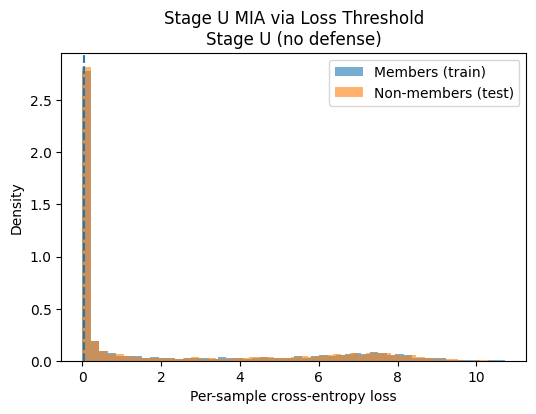


[Stage U (with clip+noise defense)]
ROC-AUC (loss-threshold attack): 0.4972  (0.5=random, 1.0=perfect)
Best attack accuracy:           0.5100  at loss threshold 0.4761


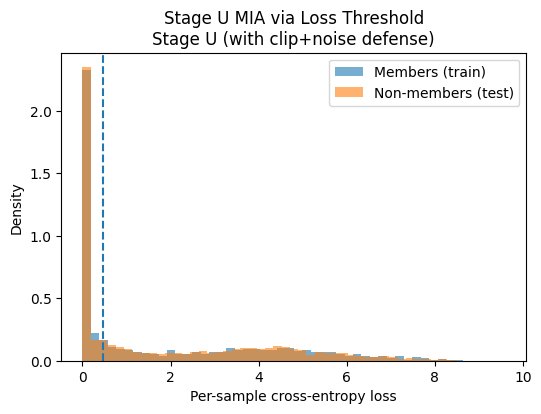


Summary:
No defense:  AUC= 0.5019862222222222  best_acc= 0.5025
With defense:AUC= 0.49724922222222223  best_acc= 0.51


In [ ]:
!pip -q install timm torchvision

import os, random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ---- Paths ----
BASE_PATH = "/content/drive/MyDrive/Sok_caseStudy"
ckpt_no_def = os.path.join(BASE_PATH, "stageU_no_defense.pt")
ckpt_def    = os.path.join(BASE_PATH, "stageU_with_defense.pt")
print("Found no_def?", os.path.exists(ckpt_no_def))
print("Found def?   ", os.path.exists(ckpt_def))

# ---- Data (same preprocessing) ----
IMG_SIZE = 64
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# ---- Model ----
def build_vit(num_classes=10):
    return timm.create_model(
        "vit_tiny_patch16_224",
        pretrained=True,
        img_size=IMG_SIZE,
        in_chans=3,
        num_classes=num_classes
    )

def load_model_from_ckpt(ckpt_path):
    model = build_vit(num_classes=10).to(device)
    state = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state, strict=True)
    model.eval()
    return model

# ---- Metrics: ROC-AUC without sklearn ----
def roc_auc_from_scores(scores, labels):
    # labels: 1=member, 0=non-member
    scores = np.asarray(scores)
    labels = np.asarray(labels).astype(int)
    order = np.argsort(scores)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(scores)) + 1.0
    pos = labels == 1
    n_pos = pos.sum()
    n_neg = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        return np.nan
    sum_ranks_pos = ranks[pos].sum()
    auc = (sum_ranks_pos - n_pos*(n_pos+1)/2.0) / (n_pos*n_neg)
    return float(auc)

def best_threshold_acc(scores, labels):
    # predict member if score <= thr (we'll use loss as score)
    scores = np.asarray(scores)
    labels = np.asarray(labels).astype(int)
    # try candidate thresholds at unique scores
    uniq = np.unique(scores)
    best = 0.0
    best_thr = None
    for thr in uniq[::max(1, len(uniq)//2000)]:  # subsample thresholds for speed
        pred = (scores <= thr).astype(int)
        acc = (pred == labels).mean()
        if acc > best:
            best = acc
            best_thr = thr
    return float(best), float(best_thr) if best_thr is not None else None

# ---- Compute per-sample losses for a set of indices ----
@torch.no_grad()
def sample_losses(model, dataset, indices, batch_size=128):
    loader = DataLoader(Subset(dataset, indices), batch_size=batch_size, shuffle=False, num_workers=2)
    losses = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y, reduction="none")
        losses.extend(loss.detach().cpu().numpy().tolist())
    return np.array(losses)

def run_stageU_mia(ckpt_path, n=5000, seed=0, title=""):
    rng = np.random.default_rng(seed)

    model = load_model_from_ckpt(ckpt_path)

    # Members: random subset from TRAIN (these are "in" Stage U training distribution)
    member_idx = rng.choice(len(train_ds), size=n, replace=False)

    # Non-members: random subset from TEST (out-of-training set)
    nonmember_idx = rng.choice(len(test_ds), size=n, replace=False)

    mem_losses  = sample_losses(model, train_ds, member_idx)
    non_losses  = sample_losses(model, test_ds, nonmember_idx)

    # Attack score: loss (lower => more likely member)
    scores = np.concatenate([mem_losses, non_losses])
    labels = np.concatenate([np.ones_like(mem_losses), np.zeros_like(non_losses)])

    auc = roc_auc_from_scores(scores, labels)
    best_acc, thr = best_threshold_acc(scores, labels)

    print(f"\n[{title}]")
    print(f"ROC-AUC (loss-threshold attack): {auc:.4f}  (0.5=random, 1.0=perfect)")
    print(f"Best attack accuracy:           {best_acc:.4f}  at loss threshold {thr:.4f}")

    # Plot distributions
    plt.figure(figsize=(6,4))
    plt.hist(mem_losses, bins=50, alpha=0.6, density=True, label="Members (train)")
    plt.hist(non_losses, bins=50, alpha=0.6, density=True, label="Non-members (test)")
    plt.axvline(thr, linestyle="--")
    plt.title(f"Stage U MIA via Loss Threshold\n{title}")
    plt.xlabel("Per-sample cross-entropy loss")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

    return {"auc": auc, "best_acc": best_acc, "thr": thr,
            "mem_losses": mem_losses, "non_losses": non_losses}

# ---- Run on both Stage U checkpoints ----
res_no = run_stageU_mia(ckpt_no_def, n=3000, seed=1, title="Stage U (no defense)")
res_dp = run_stageU_mia(ckpt_def,    n=3000, seed=1, title="Stage U (with clip+noise defense)")

print("\nSummary:")
print("No defense:  AUC=", res_no["auc"], " best_acc=", res_no["best_acc"])
print("With defense:AUC=", res_dp["auc"], " best_acc=", res_dp["best_acc"])

############################

############################

From Scratch to see Cascade for membership with Canary samples

############################

############################

In [ ]:
!pip -q install timm torchvision

import os, copy, random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------
# Repro + paths
# -------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

BASE_PATH = "/content/drive/MyDrive/Sok_caseStudy"
os.makedirs(BASE_PATH, exist_ok=True)

# -------------------------
# MNIST -> 3ch + resize
# -------------------------
IMG_SIZE = 64
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_ds_raw = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds_raw  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# -------------------------
# Canary trigger: small white patch
# Apply it ONLY to selected indices in a dataset wrapper.
# -------------------------
def apply_patch(x, size=4, value=2.0):
    # x: [3,H,W] in normalized space; value=2.0 makes it bright after clamp
    x = x.clone()
    x[:, :size, :size] = value
    return x

class TriggeredSubset(Dataset):
    """
    Wraps a base dataset. For indices in trigger_set, adds a patch trigger.
    """
    def __init__(self, base_ds, trigger_set=None, patch_size=4, patch_value=2.0):
        self.base = base_ds
        self.trigger_set = set(trigger_set) if trigger_set is not None else set()
        self.patch_size = patch_size
        self.patch_value = patch_value

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        if idx in self.trigger_set:
            x = apply_patch(x, size=self.patch_size, value=self.patch_value)
        return x, y

# Choose canary indices (members) from TRAIN
N_CANARY = 300
canary_idx = np.random.choice(len(train_ds_raw), size=N_CANARY, replace=False).tolist()
print("Num canaries:", len(canary_idx), "Example:", canary_idx[:5])

# Wrap training dataset with trigger on canary indices
train_ds = TriggeredSubset(train_ds_raw, trigger_set=canary_idx, patch_size=4, patch_value=2.0)

# For evaluation: we'll also create a triggered TEST wrapper (same trigger, but different indices)
# so member and non-member candidates have the SAME "trigger distribution".
test_ds_triggered = TriggeredSubset(test_ds_raw, trigger_set=set(range(len(test_ds_raw))), patch_size=4, patch_value=2.0)

device: cuda


100%|██████████| 9.91M/9.91M [03:43<00:00, 44.3kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 86.5kB/s]
100%|██████████| 1.65M/1.65M [00:04<00:00, 406kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.86MB/s]

Num canaries: 300 Example: [12628, 37730, 39991, 8525, 8279]


In [ ]:
# -------------------------
# FL config
# -------------------------
NUM_CLIENTS = 10
CLIENTS_PER_ROUND = 5
ROUNDS = 20
LOCAL_EPOCHS = 5
BATCH_SIZE = 64
LR = 5e-4

# Defense (clip + noise on client deltas)
CLIP_NORM = 1.0
NOISE_STD = 0.05

# -------------------------
# Build ViT "FM" + head
# -------------------------
def build_vit(num_classes=10):
    model = timm.create_model(
        "vit_tiny_patch16_224",
        pretrained=True,
        img_size=IMG_SIZE,
        in_chans=3,
        num_classes=num_classes
    )
    return model

def freeze_all_but_head(model):
    for n, p in model.named_parameters():
        p.requires_grad = ("head" in n)  # head-only FL

def get_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def load_state(model, state):
    model.load_state_dict(state, strict=True)

def get_trainable_keys(model):
    keys = []
    for k, v in model.state_dict().items():
        # state_dict includes buffers too; trainable keys are those whose parameter requires_grad=True
        # We check against named_parameters for exact trainables
        pass
    trainable = set()
    for n, p in model.named_parameters():
        if p.requires_grad:
            trainable.add(n)
    # state_dict keys differ from named_parameters keys for buffers; we map only parameters:
    for n, _ in model.named_parameters():
        if n in trainable:
            keys.append(n)
    return keys

@torch.no_grad()
def evaluate_acc(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=2)
    correct = 0; total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

def make_iid_clients(n_total, num_clients):
    idx = list(range(n_total))
    random.shuffle(idx)
    shard = n_total // num_clients
    clients = {}
    for i in range(num_clients):
        s = i * shard
        e = (i + 1) * shard if i < num_clients - 1 else n_total
        clients[i] = idx[s:e]
    return clients

client_indices = make_iid_clients(len(train_ds), NUM_CLIENTS)

# Oversample canaries inside each client to encourage memorization (stable MIA signal)
CANARY_REPEAT = 20
for cid in range(NUM_CLIENTS):
    extra = []
    for idx in client_indices[cid]:
        if idx in set(canary_idx):
            extra.extend([idx] * CANARY_REPEAT)
    client_indices[cid].extend(extra)

def compute_delta(global_state, local_state, keys):
    return {k: (local_state[k] - global_state[k]) for k in keys}

def clip_and_noise(delta, clip_norm, noise_std):
    # compute L2 norm over selected keys
    total = 0.0
    for k in delta:
        total += torch.sum(delta[k] ** 2)
    total = torch.sqrt(total + 1e-12)
    coef = min(1.0, float(clip_norm / (total.item() + 1e-12)))
    out = {}
    for k in delta:
        d = delta[k] * coef
        d = d + torch.randn_like(d) * noise_std
        out[k] = d
    return out

def local_train_one_client(global_state, indices):
    model = build_vit(num_classes=10).to(device)
    freeze_all_but_head(model)
    load_state(model, global_state)
    model.train()

    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)

    loader = DataLoader(Subset(train_ds, indices), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    for _ in range(LOCAL_EPOCHS):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()

    return get_state(model)

def run_stage_u(defense=False):
    global_model = build_vit(num_classes=10).to(device)
    freeze_all_but_head(global_model)
    global_state = get_state(global_model)
    keys = get_trainable_keys(global_model)  # should be head.weight/head.bias

    for r in range(1, ROUNDS + 1):
        selected = random.sample(range(NUM_CLIENTS), CLIENTS_PER_ROUND)
        deltas = []
        sizes = []

        for cid in selected:
            local_state = local_train_one_client(global_state, client_indices[cid])
            delta = compute_delta(global_state, local_state, keys)

            if defense:
                delta = clip_and_noise(delta, CLIP_NORM, NOISE_STD)

            deltas.append(delta)
            sizes.append(len(client_indices[cid]))

            torch.cuda.empty_cache()

        w = np.array(sizes, dtype=np.float64)
        w = w / w.sum()

        # aggregate delta into global_state (only trainable keys)
        for k in keys:
            agg = sum(float(wi) * di[k] for wi, di in zip(w, deltas))
            global_state[k] = global_state[k] + agg

        load_state(global_model, global_state)
        acc = evaluate_acc(global_model, test_ds_raw)
        tag = "DEF" if defense else "NO-DEF"
        print(f"[StageU-{tag}] Round {r:02d}/{ROUNDS} | test acc: {acc:.4f}")

    return global_state

# Train and save both artifacts
state_no_def = run_stage_u(defense=False)
path_no_def = os.path.join(BASE_PATH, "stageU_no_defense.pt")
torch.save(state_no_def, path_no_def)

state_def = run_stage_u(defense=True)
path_def = os.path.join(BASE_PATH, "stageU_with_defense.pt")
torch.save(state_def, path_def)

# Save canary indices (so Stage D can reuse same probe set later)
np.save(os.path.join(BASE_PATH, "canary_indices.npy"), np.array(canary_idx, dtype=np.int64))

print("Saved:", path_no_def)
print("Saved:", path_def)
print("Saved canaries:", os.path.join(BASE_PATH, "canary_indices.npy"))

[StageU-NO-DEF] Round 01/20 | test acc: 0.7379
[StageU-NO-DEF] Round 02/20 | test acc: 0.7752
[StageU-NO-DEF] Round 03/20 | test acc: 0.7920
[StageU-NO-DEF] Round 04/20 | test acc: 0.7973
[StageU-NO-DEF] Round 05/20 | test acc: 0.8029
[StageU-NO-DEF] Round 06/20 | test acc: 0.8047
[StageU-NO-DEF] Round 07/20 | test acc: 0.8079
[StageU-NO-DEF] Round 08/20 | test acc: 0.8120
[StageU-NO-DEF] Round 09/20 | test acc: 0.8151
[StageU-NO-DEF] Round 10/20 | test acc: 0.8169
[StageU-NO-DEF] Round 11/20 | test acc: 0.8200
[StageU-NO-DEF] Round 12/20 | test acc: 0.8210
[StageU-NO-DEF] Round 13/20 | test acc: 0.8235
[StageU-NO-DEF] Round 14/20 | test acc: 0.8252
[StageU-NO-DEF] Round 15/20 | test acc: 0.8249
[StageU-NO-DEF] Round 16/20 | test acc: 0.8235
[StageU-NO-DEF] Round 17/20 | test acc: 0.8244
[StageU-NO-DEF] Round 18/20 | test acc: 0.8250
[StageU-NO-DEF] Round 19/20 | test acc: 0.8296
[StageU-NO-DEF] Round 20/20 | test acc: 0.8287
[StageU-DEF] Round 01/20 | test acc: 0.5735
[StageU-DEF] Rou


Stage U (no defense)
ROC-AUC: 0.4876 (0.5=random)
Best acc: 0.5500 at loss <= 1.0296

Stage U (with clip+noise)
ROC-AUC: 0.4847 (0.5=random)
Best acc: 0.5483 at loss <= 1.5157


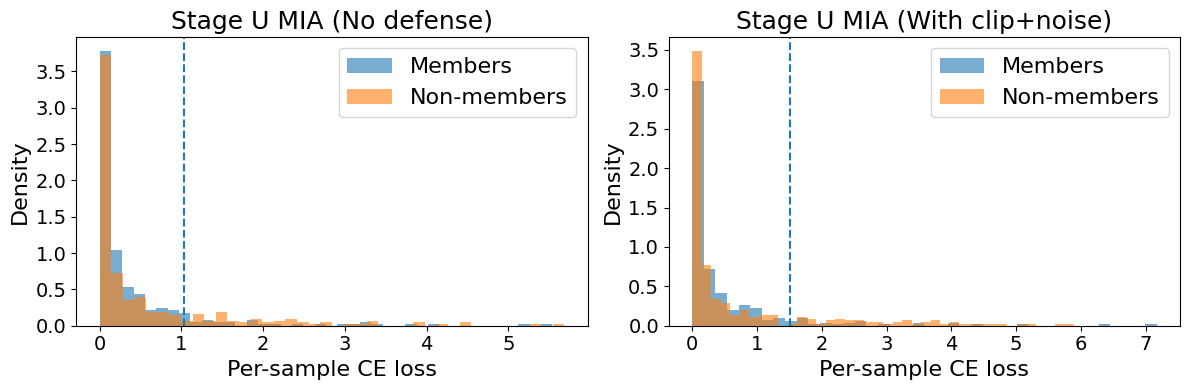

Saved figure: /content/drive/MyDrive/Sok_caseStudy/stageU_mia_hist.png
Saved table CSV: /content/drive/MyDrive/Sok_caseStudy/stageU_mia_results.csv


,Stage,Defense,Attack,AUC,BestAcc
0,U,None,Loss-threshold MIA (canary),0.487589,0.550000
1,U,Clip+Noise,Loss-threshold MIA (canary),0.484744,0.548333


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import pandas as pd
import matplotlib.pyplot as plt

def load_model_from_state(state_path):
    model = build_vit(num_classes=10).to(device)
    freeze_all_but_head(model)
    st = torch.load(state_path, map_location="cpu")
    model.load_state_dict(st, strict=True)
    model.eval()
    return model

@torch.no_grad()
def per_sample_losses(model, dataset, indices, bs=128):
    loader = DataLoader(Subset(dataset, indices), batch_size=bs, shuffle=False, num_workers=2)
    out = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y, reduction="none")
        out.extend(loss.detach().cpu().numpy().tolist())
    return np.array(out)

def roc_auc(scores, labels):
    scores = np.asarray(scores)
    labels = np.asarray(labels).astype(int)
    order = np.argsort(scores)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(scores)) + 1.0
    pos = labels == 1
    n_pos = pos.sum()
    n_neg = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        return np.nan
    sum_ranks_pos = ranks[pos].sum()
    auc = (sum_ranks_pos - n_pos*(n_pos+1)/2.0) / (n_pos*n_neg)
    return float(auc)

def best_thresh_acc(losses, labels):
    losses = np.asarray(losses)
    labels = np.asarray(labels).astype(int)
    uniq = np.unique(losses)
    # subsample candidate thresholds for speed
    step = max(1, len(uniq)//2000)
    best_acc, best_thr = 0.0, None
    for thr in uniq[::step]:
        pred = (losses <= thr).astype(int)  # low loss => member
        acc = (pred == labels).mean()
        if acc > best_acc:
            best_acc, best_thr = acc, thr
    return float(best_acc), float(best_thr)

# Load canaries
canary_idx = np.load(os.path.join(BASE_PATH, "canary_indices.npy")).tolist()

# Build non-member candidates: triggered TEST indices (same size as canaries)
rng = np.random.default_rng(SEED)
nonmember_test_idx = rng.choice(len(test_ds_raw), size=len(canary_idx), replace=False).tolist()

# Note:
# - Members are triggered via train_ds wrapper (trigger applied only to canary indices)
# - Nonmembers come from test_ds_triggered where ALL test samples are triggered
# This matches distributions of "triggered samples" across member/nonmember.

def run_mia_for_checkpoint(state_path, title):
    model = load_model_from_state(state_path)

    mem_losses = per_sample_losses(model, train_ds, canary_idx)                 # triggered canaries (members)
    non_losses = per_sample_losses(model, test_ds_triggered, nonmember_test_idx) # triggered test samples (nonmembers)

    losses = np.concatenate([mem_losses, non_losses])
    labels = np.concatenate([np.ones_like(mem_losses), np.zeros_like(non_losses)])

    auc = roc_auc(losses, labels)
    best_acc, thr = best_thresh_acc(losses, labels)

    print(f"\n{title}")
    print(f"ROC-AUC: {auc:.4f} (0.5=random)")
    print(f"Best acc: {best_acc:.4f} at loss <= {thr:.4f}")

    return auc, best_acc, thr, mem_losses, non_losses

auc0, acc0, thr0, mem0, non0 = run_mia_for_checkpoint(path_no_def, "Stage U (no defense)")
auc1, acc1, thr1, mem1, non1 = run_mia_for_checkpoint(path_def,    "Stage U (with clip+noise)")


# --- Paper-ready figure: two panels (no-def vs def) ---
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(mem0, bins=40, alpha=0.6, density=True, label="Members")
plt.hist(non0, bins=40, alpha=0.6, density=True, label="Non-members")
plt.axvline(thr0, linestyle="--")

plt.title("Stage U MIA (No defense)", fontsize=18)
plt.xlabel("Per-sample CE loss", fontsize=16)
plt.ylabel("Density", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)

plt.subplot(1,2,2)
plt.hist(mem1, bins=40, alpha=0.6, density=True, label="Members")
plt.hist(non1, bins=40, alpha=0.6, density=True, label="Non-members")
plt.axvline(thr1, linestyle="--")

plt.title("Stage U MIA (With clip+noise)", fontsize=18)
plt.xlabel("Per-sample CE loss", fontsize=16)
plt.ylabel("Density", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)

fig_path = os.path.join(BASE_PATH, "stageU_mia_hist.png")
plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure:", fig_path)

# --- Paper-ready table (CSV) ---
df = pd.DataFrame([
    {"Stage": "U", "Defense": "None", "Attack": "Loss-threshold MIA (canary)", "AUC": auc0, "BestAcc": acc0},
    {"Stage": "U", "Defense": "Clip+Noise", "Attack": "Loss-threshold MIA (canary)", "AUC": auc1, "BestAcc": acc1},
])
csv_path = os.path.join(BASE_PATH, "stageU_mia_results.csv")
df.to_csv(csv_path, index=False)
print("Saved table CSV:", csv_path)

df

Output from the above code:

##Output 1

Stage U (no defense)

ROC-AUC: 0.5040 (0.5=random)

Best acc: 0.5333 at loss <= 1.1610

Stage U (with clip+noise)

ROC-AUC: 0.4957 (0.5=random)

Best acc: 0.5367 at loss <= 2.0241

Stage	Defense	Attack	AUC	BestAcc

0	U	None	Loss-threshold MIA (canary)	0.504011	0.533333

1	U	Clip+Noise	Loss-threshold MIA (canary)	0.495667	0.536667


############################

############################

From Scratch to see Cascade for membership with Canary samples (CIFR10)

############################

############################

device: cuda
Num canaries: 500
Example client labels: [8, 7]
[StageU-NO-DEF] Round 01/20 | test acc: 0.1706
[StageU-NO-DEF] Round 02/20 | test acc: 0.2756
[StageU-NO-DEF] Round 03/20 | test acc: 0.3048
[StageU-NO-DEF] Round 04/20 | test acc: 0.3407
[StageU-NO-DEF] Round 05/20 | test acc: 0.3587
[StageU-NO-DEF] Round 06/20 | test acc: 0.3539
[StageU-NO-DEF] Round 07/20 | test acc: 0.3195
[StageU-NO-DEF] Round 08/20 | test acc: 0.3931
[StageU-NO-DEF] Round 09/20 | test acc: 0.2631
[StageU-NO-DEF] Round 10/20 | test acc: 0.4439
[StageU-NO-DEF] Round 11/20 | test acc: 0.3689
[StageU-NO-DEF] Round 12/20 | test acc: 0.4369
[StageU-NO-DEF] Round 13/20 | test acc: 0.3543
[StageU-NO-DEF] Round 14/20 | test acc: 0.2772
[StageU-NO-DEF] Round 15/20 | test acc: 0.3548
[StageU-NO-DEF] Round 16/20 | test acc: 0.4384
[StageU-NO-DEF] Round 17/20 | test acc: 0.3182
[StageU-NO-DEF] Round 18/20 | test acc: 0.3913
[StageU-NO-DEF] Round 19/20 | test acc: 0.4092
[StageU-NO-DEF] Round 20/20 | test acc: 0.4319

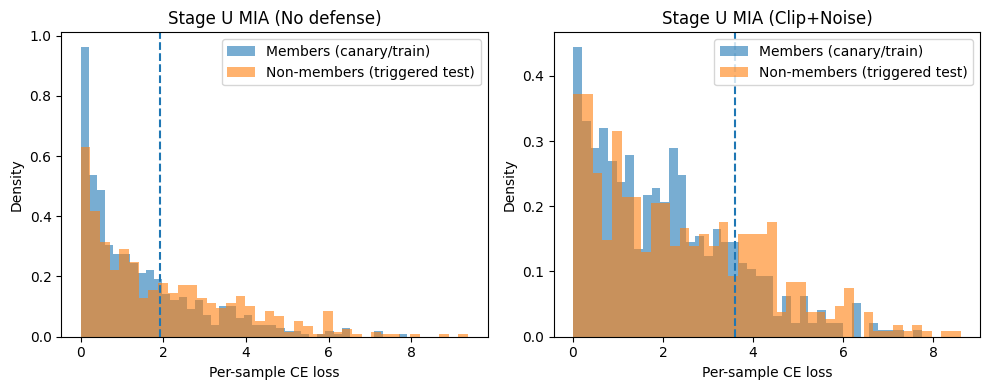

Saved figure: /content/drive/MyDrive/Sok_caseStudy/stageU_cifar10_mia_hist.png
Saved CSV: /content/drive/MyDrive/Sok_caseStudy/stageU_cifar10_mia_results.csv


,Stage,Dataset,Defense,Attack,AUC,BestAcc
0,U,CIFAR-10,None,Loss-threshold MIA (canary),0.586536,0.578
1,U,CIFAR-10,Clip+Noise,Loss-threshold MIA (canary),0.551088,0.555


In [ ]:
# =========================
# Stage U (FL-for-FMs) Case Study — CIFAR-10 + ViT-tiny
# - Simulated FL (clients + FedAvg) with non-IID partition
# - Two runs: no defense vs clip+noise defense on client deltas
# - Membership inference (loss-threshold) using CANARY members (triggered train samples)
# - Outputs: figure PNG + results CSV (paper-ready)
# =========================

!pip -q install timm torchvision pandas

import os, copy, random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------
# Repro + device + paths
# -------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

BASE_PATH = "/content/drive/MyDrive/Sok_caseStudy"
os.makedirs(BASE_PATH, exist_ok=True)

# -------------------------
# CIFAR-10 preprocessing
# Keep it simple for memorization signal (no heavy aug)
# -------------------------
IMG_SIZE = 64
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_raw = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
test_raw  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

# -------------------------
# Canary trigger: corner patch
# -------------------------
def apply_patch(x, size=6, value=2.0):
    x = x.clone()
    x[:, :size, :size] = value
    return x

class TriggeredSubsetDS(Dataset):
    """
    Wrap a base dataset and apply a trigger to specified indices.
    """
    def __init__(self, base_ds, trigger_set=None, patch_size=6, patch_value=2.0):
        self.base = base_ds
        self.trigger_set = set(trigger_set) if trigger_set is not None else set()
        self.patch_size = patch_size
        self.patch_value = patch_value

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        if idx in self.trigger_set:
            x = apply_patch(x, size=self.patch_size, value=self.patch_value)
        return x, y

# Pick canary indices from TRAIN (members)
N_CANARY = 500
canary_idx = np.random.choice(len(train_raw), size=N_CANARY, replace=False).tolist()

# Training dataset: only canaries are triggered
train_ds = TriggeredSubsetDS(train_raw, trigger_set=canary_idx, patch_size=6, patch_value=2.0)

# Non-member candidates: triggered TEST samples (ALL test are triggered for distribution matching)
test_ds_triggered_all = TriggeredSubsetDS(test_raw, trigger_set=set(range(len(test_raw))), patch_size=6, patch_value=2.0)

print("Num canaries:", len(canary_idx))

# -------------------------
# Non-IID client partition (2 labels per client)
# -------------------------
def make_noniid_clients_by_labels(dataset, num_clients=20, labels_per_client=2):
    label_to_indices = {c: [] for c in range(10)}
    for i in range(len(dataset)):
        _, y = dataset[i]
        label_to_indices[int(y)].append(i)

    for c in label_to_indices:
        random.shuffle(label_to_indices[c])

    clients = {i: [] for i in range(num_clients)}
    all_labels = list(range(10))
    client_labels = []
    per_client = len(dataset) // num_clients

    for i in range(num_clients):
        chosen = random.sample(all_labels, labels_per_client)
        client_labels.append(chosen)
        while len(clients[i]) < per_client:
            y = random.choice(chosen)
            if label_to_indices[y]:
                clients[i].append(label_to_indices[y].pop())
            else:
                # fallback
                for yy in all_labels:
                    if label_to_indices[yy]:
                        clients[i].append(label_to_indices[yy].pop())
                        break
                else:
                    break

    return clients, client_labels

NUM_CLIENTS = 20
LABELS_PER_CLIENT = 2
client_indices, client_labels = make_noniid_clients_by_labels(train_ds, NUM_CLIENTS, LABELS_PER_CLIENT)

# Oversample canaries inside each client to encourage memorization signal
CANARY_REPEAT = 3
canary_set = set(canary_idx)
for cid in range(NUM_CLIENTS):
    extra = [idx for idx in client_indices[cid] if idx in canary_set]
    client_indices[cid].extend(extra * CANARY_REPEAT)

print("Example client labels:", client_labels[0])

# -------------------------
# ViT model (FM-like backbone)
# Train head + last transformer block (stronger leakage than head-only, still feasible)
# -------------------------
def build_vit(num_classes=10):
    model = timm.create_model(
        "vit_tiny_patch16_224",
        pretrained=True,
        img_size=IMG_SIZE,
        in_chans=3,
        num_classes=num_classes
    )
    return model

def set_trainable_head_lastblock(model):
    for n, p in model.named_parameters():
        p.requires_grad = False
        if n.startswith("head."):
            p.requires_grad = True
        # last block for extra capacity/memorization
        if "blocks.11." in n:  # vit_tiny has 12 blocks: 0..11
            p.requires_grad = True
        if n.startswith("norm."):  # final norm can be trainable too
            p.requires_grad = True

def get_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def load_state(model, state):
    model.load_state_dict(state, strict=True)

def trainable_param_names(model):
    return [n for n, p in model.named_parameters() if p.requires_grad]

@torch.no_grad()
def evaluate_acc(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=2)
    correct = 0; total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

# -------------------------
# FL training utilities
# -------------------------
BATCH_SIZE = 64
ROUNDS = 20
CLIENTS_PER_ROUND = 5
LOCAL_EPOCHS = 5
LR = 5e-4

# Defense (clip+noise on deltas for trainable params only)
CLIP_NORM = 1.0
NOISE_STD = 0.02

def local_train_one_client(global_state, indices):
    model = build_vit(num_classes=10).to(device)
    set_trainable_head_lastblock(model)
    load_state(model, global_state)
    model.train()

    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)

    loader = DataLoader(Subset(train_ds, indices), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    for _ in range(LOCAL_EPOCHS):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()

    return get_state(model)

def compute_delta(global_state, local_state, keys):
    return {k: (local_state[k] - global_state[k]) for k in keys}

def clip_and_noise(delta, clip_norm, noise_std):
    total = 0.0
    for k in delta:
        total += torch.sum(delta[k] ** 2)
    total = torch.sqrt(total + 1e-12)
    coef = min(1.0, float(clip_norm / (total.item() + 1e-12)))
    out = {}
    for k in delta:
        d = delta[k] * coef
        d = d + torch.randn_like(d) * noise_std
        out[k] = d
    return out

def run_stage_u(defense=False):
    global_model = build_vit(num_classes=10).to(device)
    set_trainable_head_lastblock(global_model)
    global_state = get_state(global_model)

    # Trainable keys in state_dict for aggregation:
    trainable = set(trainable_param_names(global_model))
    keys = [k for k in global_state.keys() if k in trainable]

    for r in range(1, ROUNDS + 1):
        selected = random.sample(range(NUM_CLIENTS), CLIENTS_PER_ROUND)
        deltas = []
        sizes = []

        for cid in selected:
            local_state = local_train_one_client(global_state, client_indices[cid])
            delta = compute_delta(global_state, local_state, keys)
            if defense:
                delta = clip_and_noise(delta, CLIP_NORM, NOISE_STD)
            deltas.append(delta)
            sizes.append(len(client_indices[cid]))
            torch.cuda.empty_cache()

        w = np.array(sizes, dtype=np.float64)
        w = w / w.sum()

        for k in keys:
            global_state[k] = global_state[k] + sum(float(wi) * di[k] for wi, di in zip(w, deltas))

        load_state(global_model, global_state)
        acc = evaluate_acc(global_model, test_raw)
        tag = "DEF" if defense else "NO-DEF"
        print(f"[StageU-{tag}] Round {r:02d}/{ROUNDS} | test acc: {acc:.4f}")

    return global_state

# -------------------------
# Train both Stage-U artifacts and save
# -------------------------
state_no_def = run_stage_u(defense=False)
path_no_def = os.path.join(BASE_PATH, "stageU_cifar10_no_defense.pt")
torch.save(state_no_def, path_no_def)

state_def = run_stage_u(defense=True)
path_def = os.path.join(BASE_PATH, "stageU_cifar10_with_defense.pt")
torch.save(state_def, path_def)

np.save(os.path.join(BASE_PATH, "cifar10_canary_indices.npy"), np.array(canary_idx, dtype=np.int64))

print("Saved:", path_no_def)
print("Saved:", path_def)

# -------------------------
# Membership inference (loss-threshold) on triggered canaries
# - Members: triggered TRAIN canaries
# - Non-members: triggered TEST samples (same size)
# -------------------------
def load_model_from_state(state_path):
    model = build_vit(num_classes=10).to(device)
    set_trainable_head_lastblock(model)
    st = torch.load(state_path, map_location="cpu")
    model.load_state_dict(st, strict=True)
    model.eval()
    return model

@torch.no_grad()
def per_sample_losses(model, dataset, indices, bs=128):
    loader = DataLoader(Subset(dataset, indices), batch_size=bs, shuffle=False, num_workers=2)
    out = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y, reduction="none")
        out.extend(loss.detach().cpu().numpy().tolist())
    return np.array(out)

def roc_auc(scores, labels):
    scores = np.asarray(scores)
    labels = np.asarray(labels).astype(int)
    order = np.argsort(scores)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(scores)) + 1.0
    pos = labels == 1
    n_pos = pos.sum()
    n_neg = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        return np.nan
    sum_ranks_pos = ranks[pos].sum()
    auc = (sum_ranks_pos - n_pos*(n_pos+1)/2.0) / (n_pos*n_neg)
    return float(auc)

def best_thresh_acc(losses, labels):
    losses = np.asarray(losses)
    labels = np.asarray(labels).astype(int)
    uniq = np.unique(losses)
    step = max(1, len(uniq)//2000)
    best_acc, best_thr = 0.0, None
    for thr in uniq[::step]:
        pred = (losses <= thr).astype(int)
        acc = (pred == labels).mean()
        if acc > best_acc:
            best_acc, best_thr = acc, thr
    return float(best_acc), float(best_thr)

rng = np.random.default_rng(SEED)
nonmember_test_idx = rng.choice(len(test_raw), size=len(canary_idx), replace=False).tolist()

def run_mia(state_path, title):
    model = load_model_from_state(state_path)

    # Members: triggered canaries in TRAIN
    mem_losses = per_sample_losses(model, train_ds, canary_idx)

    # Non-members: triggered samples in TEST (distribution-matched trigger)
    non_losses = per_sample_losses(model, test_ds_triggered_all, nonmember_test_idx)

    losses = np.concatenate([mem_losses, non_losses])
    labels = np.concatenate([np.ones_like(mem_losses), np.zeros_like(non_losses)])

    # IMPORTANT: AUC expects higher score => more likely positive (member)
    scores = -losses
    auc = roc_auc(scores, labels)

    # Keep classic loss-threshold attack: predict member if loss <= thr
    best_acc, thr = best_thresh_acc(losses, labels)

    print(f"\n{title}")
    print(f"ROC-AUC: {auc:.4f}  (using score = -loss)")
    print(f"BestAcc: {best_acc:.4f} @ loss <= {thr:.4f}")

    return auc, best_acc, thr, mem_losses, non_losses


auc0, acc0, thr0, mem0, non0 = run_mia(path_no_def, "Stage U (CIFAR-10, no defense)")
auc1, acc1, thr1, mem1, non1 = run_mia(path_def,    "Stage U (CIFAR-10, clip+noise)")

# -------------------------
# Paper-ready figure + CSV table
# -------------------------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(mem0, bins=40, alpha=0.6, density=True, label="Members (canary/train)")
plt.hist(non0, bins=40, alpha=0.6, density=True, label="Non-members (triggered test)")
plt.axvline(thr0, linestyle="--")
plt.title("Stage U MIA (No defense)")
plt.xlabel("Per-sample CE loss"); plt.ylabel("Density"); plt.legend()

plt.subplot(1,2,2)
plt.hist(mem1, bins=40, alpha=0.6, density=True, label="Members (canary/train)")
plt.hist(non1, bins=40, alpha=0.6, density=True, label="Non-members (triggered test)")
plt.axvline(thr1, linestyle="--")
plt.title("Stage U MIA (Clip+Noise)")
plt.xlabel("Per-sample CE loss"); plt.ylabel("Density"); plt.legend()

fig_path = os.path.join(BASE_PATH, "stageU_cifar10_mia_hist.png")
plt.tight_layout()
plt.savefig(fig_path, dpi=200)
plt.show()
print("Saved figure:", fig_path)

df = pd.DataFrame([
    {"Stage": "U", "Dataset": "CIFAR-10", "Defense": "None",      "Attack": "Loss-threshold MIA (canary)", "AUC": auc0, "BestAcc": acc0},
    {"Stage": "U", "Dataset": "CIFAR-10", "Defense": "Clip+Noise","Attack": "Loss-threshold MIA (canary)", "AUC": auc1, "BestAcc": acc1},
])
csv_path = os.path.join(BASE_PATH, "stageU_cifar10_mia_results.csv")
df.to_csv(csv_path, index=False)
print("Saved CSV:", csv_path)

df

##Output from above

Stage U (CIFAR-10, no defense)
ROC-AUC: 0.5865  (using score = -loss)
BestAcc: 0.5780 @ loss <= 1.9187

Stage U (CIFAR-10, clip+noise)
ROC-AUC: 0.5511  (using score = -loss)
BestAcc: 0.5550 @ loss <= 3.5922


Stage	Dataset	Defense	Attack	AUC	BestAcc
0	U	CIFAR-10	None	Loss-threshold MIA (canary)	0.586536	0.578
1	U	CIFAR-10	Clip+Noise	Loss-threshold MIA (canary)	0.551088	0.555


########################

#########################

##Stage D testing

########################

#########################

device: cuda
Loaded canaries: 500
Stage D example client labels: [8, 7]
[D-scratch] Round 01/15 | test acc: 0.1502
[D-scratch] Round 02/15 | test acc: 0.1465
[D-scratch] Round 03/15 | test acc: 0.2502
[D-scratch] Round 04/15 | test acc: 0.2778
[D-scratch] Round 05/15 | test acc: 0.2975
[D-scratch] Round 06/15 | test acc: 0.2555
[D-scratch] Round 07/15 | test acc: 0.2328
[D-scratch] Round 08/15 | test acc: 0.2580
[D-scratch] Round 09/15 | test acc: 0.2647
[D-scratch] Round 10/15 | test acc: 0.3382
[D-scratch] Round 11/15 | test acc: 0.2593
[D-scratch] Round 12/15 | test acc: 0.2319
[D-scratch] Round 13/15 | test acc: 0.3560
[D-scratch] Round 14/15 | test acc: 0.2448
[D-scratch] Round 15/15 | test acc: 0.2552
[D-from-U(no-def)] Round 01/15 | test acc: 0.3963
[D-from-U(no-def)] Round 02/15 | test acc: 0.3619
[D-from-U(no-def)] Round 03/15 | test acc: 0.4151
[D-from-U(no-def)] Round 04/15 | test acc: 0.4425
[D-from-U(no-def)] Round 05/15 | test acc: 0.4268
[D-from-U(no-def)] Round 06/15 | 

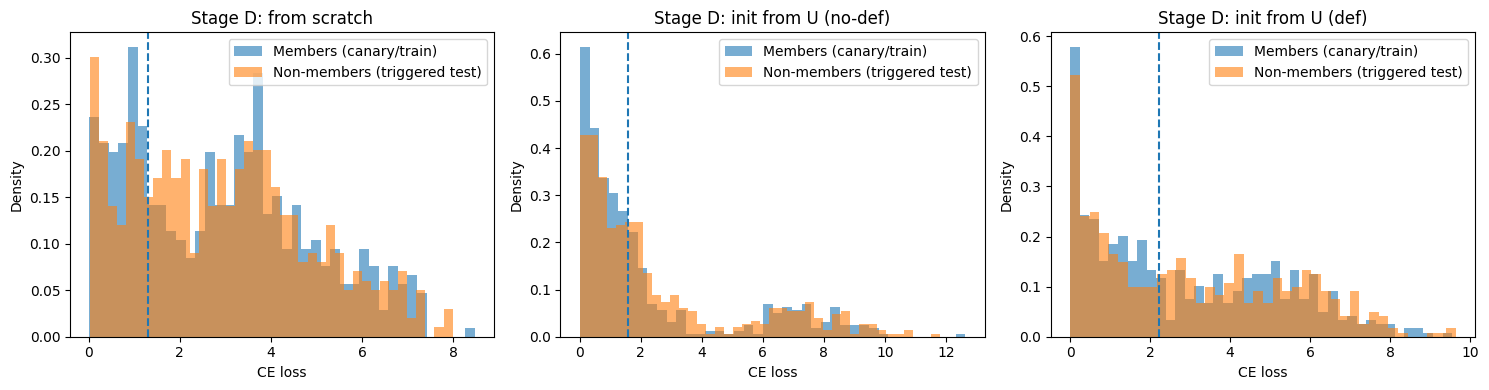

Saved figure: /content/drive/MyDrive/Sok_caseStudy/stageD_cifar10_mia_hist.png
Saved CSV: /content/drive/MyDrive/Sok_caseStudy/stageD_cifar10_mia_results.csv


,Stage,Init,Defense(U),Attack,AUC,BestAcc
0,D,Scratch,N/A,Loss-threshold MIA (canary),0.503040,0.526
1,D,From-U,None,Loss-threshold MIA (canary),0.555732,0.556
2,D,From-U,Clip+Noise,Loss-threshold MIA (canary),0.519272,0.531


In [ ]:
# =========================
# Stage D (FMs-in-FL) — CIFAR-10 + ViT-tiny
# Three initializations: D-scratch, U->D(no-def), U->D(def)
# Freeze backbone, train head via FL, then MIA on canaries
# Outputs: figure PNG + CSV table
# =========================

import os, copy, random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------
# Repro + device + paths
# -------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

BASE_PATH = "/content/drive/MyDrive/Sok_caseStudy"
u_no_def_path = os.path.join(BASE_PATH, "stageU_cifar10_no_defense.pt")
u_def_path    = os.path.join(BASE_PATH, "stageU_cifar10_with_defense.pt")
canary_path   = os.path.join(BASE_PATH, "cifar10_canary_indices.npy")

assert os.path.exists(u_no_def_path), f"Missing {u_no_def_path}"
assert os.path.exists(u_def_path),    f"Missing {u_def_path}"
assert os.path.exists(canary_path),   f"Missing {canary_path}"

# -------------------------
# CIFAR-10 preprocessing (must match Stage U)
# -------------------------
IMG_SIZE = 64
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_raw = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_raw  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

# -------------------------
# Canary trigger (must match Stage U)
# -------------------------
def apply_patch(x, size=6, value=2.0):
    x = x.clone()
    x[:, :size, :size] = value
    return x

class TriggeredSubsetDS(Dataset):
    def __init__(self, base_ds, trigger_set=None, patch_size=6, patch_value=2.0):
        self.base = base_ds
        self.trigger_set = set(trigger_set) if trigger_set is not None else set()
        self.patch_size = patch_size
        self.patch_value = patch_value

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        if idx in self.trigger_set:
            x = apply_patch(x, size=self.patch_size, value=self.patch_value)
        return x, y

canary_idx = np.load(canary_path).astype(int).tolist()
canary_set = set(canary_idx)
print("Loaded canaries:", len(canary_idx))

# Stage D training dataset:
# IMPORTANT: we keep the same canary probe concept (triggered canaries in TRAIN)
train_ds = TriggeredSubsetDS(train_raw, trigger_set=canary_set, patch_size=6, patch_value=2.0)

# Non-member evaluation dataset: triggered TEST (all test samples triggered for distribution matching)
test_ds_triggered_all = TriggeredSubsetDS(test_raw, trigger_set=set(range(len(test_raw))), patch_size=6, patch_value=2.0)

# -------------------------
# Non-IID clients for Stage D (same style)
# -------------------------
def make_noniid_clients_by_labels(dataset, num_clients=20, labels_per_client=2):
    label_to_indices = {c: [] for c in range(10)}
    for i in range(len(dataset)):
        _, y = dataset[i]
        label_to_indices[int(y)].append(i)
    for c in label_to_indices:
        random.shuffle(label_to_indices[c])

    clients = {i: [] for i in range(num_clients)}
    all_labels = list(range(10))
    client_labels = []
    per_client = len(dataset) // num_clients

    for i in range(num_clients):
        chosen = random.sample(all_labels, labels_per_client)
        client_labels.append(chosen)
        while len(clients[i]) < per_client:
            y = random.choice(chosen)
            if label_to_indices[y]:
                clients[i].append(label_to_indices[y].pop())
            else:
                for yy in all_labels:
                    if label_to_indices[yy]:
                        clients[i].append(label_to_indices[yy].pop())
                        break
                else:
                    break
    return clients, client_labels

NUM_CLIENTS = 20
LABELS_PER_CLIENT = 2
client_indices, client_labels = make_noniid_clients_by_labels(train_ds, NUM_CLIENTS, LABELS_PER_CLIENT)
print("Stage D example client labels:", client_labels[0])

# Increase canary exposure to make Stage D memorization visible (helps cascade)
CANARY_REPEAT_D = 10
for cid in range(NUM_CLIENTS):
    extra = [idx for idx in client_indices[cid] if idx in canary_set]
    client_indices[cid].extend(extra * CANARY_REPEAT_D)

# -------------------------
# Build ViT and freezing for Stage D
# -------------------------
def build_vit(num_classes=10):
    return timm.create_model(
        "vit_tiny_patch16_224",
        pretrained=True,
        img_size=IMG_SIZE,
        in_chans=3,
        num_classes=num_classes
    )

def set_trainable_head_only(model):
    for n, p in model.named_parameters():
        p.requires_grad = n.startswith("head.")

def get_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def load_state(model, state):
    model.load_state_dict(state, strict=True)

@torch.no_grad()
def evaluate_acc(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=2)
    correct = 0; total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

# -------------------------
# Stage D FL training
# -------------------------
BATCH_SIZE = 64
ROUNDS_D = 15
CLIENTS_PER_ROUND_D = 5
LOCAL_EPOCHS_D = 5
LR_D = 5e-4

def local_train_client_head(global_state, indices):
    model = build_vit(num_classes=10).to(device)
    set_trainable_head_only(model)
    load_state(model, global_state)
    model.train()

    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR_D)
    loader = DataLoader(Subset(train_ds, indices), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

    for _ in range(LOCAL_EPOCHS_D):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()

    return get_state(model)

def run_stage_d(init_state=None, tag="D"):
    """
    init_state: None => start from base pretrained ViT (scratch for Stage D)
             dict => load as initialization (U->D)
    """
    model = build_vit(num_classes=10).to(device)
    set_trainable_head_only(model)

    if init_state is not None:
        load_state(model, init_state)

    global_state = get_state(model)

    # head keys only
    head_keys = [k for k in global_state.keys() if k.startswith("head.")]

    for r in range(1, ROUNDS_D + 1):
        selected = random.sample(range(NUM_CLIENTS), CLIENTS_PER_ROUND_D)
        deltas = []
        sizes = []

        for cid in selected:
            local_state = local_train_client_head(global_state, client_indices[cid])
            delta = {k: (local_state[k] - global_state[k]) for k in head_keys}
            deltas.append(delta)
            sizes.append(len(client_indices[cid]))
            torch.cuda.empty_cache()

        w = np.array(sizes, dtype=np.float64)
        w = w / w.sum()

        for k in head_keys:
            global_state[k] = global_state[k] + sum(float(wi) * di[k] for wi, di in zip(w, deltas))

        load_state(model, global_state)
        acc = evaluate_acc(model, test_raw)
        print(f"[{tag}] Round {r:02d}/{ROUNDS_D} | test acc: {acc:.4f}")

    return global_state

# Load Stage U initializations
u_no_def_state = torch.load(u_no_def_path, map_location="cpu")
u_def_state    = torch.load(u_def_path, map_location="cpu")

# -------------------------
# Run 3 Stage D conditions
# -------------------------
d_scratch_state = run_stage_d(init_state=None, tag="D-scratch")
d_from_u_no_state = run_stage_d(init_state=u_no_def_state, tag="D-from-U(no-def)")
d_from_u_def_state = run_stage_d(init_state=u_def_state, tag="D-from-U(def)")

# Save Stage D checkpoints
d_scratch_path = os.path.join(BASE_PATH, "stageD_cifar10_from_scratch.pt")
d_u_no_path    = os.path.join(BASE_PATH, "stageD_cifar10_from_U_no_def.pt")
d_u_def_path   = os.path.join(BASE_PATH, "stageD_cifar10_from_U_def.pt")

torch.save(d_scratch_state, d_scratch_path)
torch.save(d_from_u_no_state, d_u_no_path)
torch.save(d_from_u_def_state, d_u_def_path)

print("Saved Stage D:", d_scratch_path)
print("Saved Stage D:", d_u_no_path)
print("Saved Stage D:", d_u_def_path)

# -------------------------
# MIA evaluation (same canaries)
# -------------------------
@torch.no_grad()
def per_sample_losses(model, dataset, indices, bs=128):
    loader = DataLoader(Subset(dataset, indices), batch_size=bs, shuffle=False, num_workers=2)
    out = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y, reduction="none")
        out.extend(loss.detach().cpu().numpy().tolist())
    return np.array(out)

def roc_auc(scores, labels):
    scores = np.asarray(scores)
    labels = np.asarray(labels).astype(int)
    order = np.argsort(scores)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(scores)) + 1.0
    pos = labels == 1
    n_pos = pos.sum()
    n_neg = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        return np.nan
    sum_ranks_pos = ranks[pos].sum()
    auc = (sum_ranks_pos - n_pos*(n_pos+1)/2.0) / (n_pos*n_neg)
    return float(auc)

def best_thresh_acc(losses, labels):
    losses = np.asarray(losses)
    labels = np.asarray(labels).astype(int)
    uniq = np.unique(losses)
    step = max(1, len(uniq)//2000)
    best_acc, best_thr = 0.0, None
    for thr in uniq[::step]:
        pred = (losses <= thr).astype(int)  # low loss => member
        acc = (pred == labels).mean()
        if acc > best_acc:
            best_acc, best_thr = acc, thr
    return float(best_acc), float(best_thr)

rng = np.random.default_rng(SEED)
nonmember_test_idx = rng.choice(len(test_raw), size=len(canary_idx), replace=False).tolist()

def load_model_from_state_dict(state_dict):
    m = build_vit(num_classes=10).to(device)
    set_trainable_head_only(m)  # same training setting
    m.load_state_dict(state_dict, strict=True)
    m.eval()
    return m

def run_mia_on_state(state_dict, title):
    model = load_model_from_state_dict(state_dict)

    mem_losses = per_sample_losses(model, train_ds, canary_idx)
    non_losses = per_sample_losses(model, test_ds_triggered_all, nonmember_test_idx)

    losses = np.concatenate([mem_losses, non_losses])
    labels = np.concatenate([np.ones_like(mem_losses), np.zeros_like(non_losses)])

    scores = -losses  # higher score => more likely member
    auc = roc_auc(scores, labels)
    best_acc, thr = best_thresh_acc(losses, labels)

    print(f"\n{title}")
    print(f"ROC-AUC: {auc:.4f}")
    print(f"BestAcc: {best_acc:.4f} @ loss <= {thr:.4f}")

    return auc, best_acc, thr, mem_losses, non_losses

auc_s, acc_s, thr_s, mem_s, non_s = run_mia_on_state(d_scratch_state, "Stage D (from scratch)")
auc_u0, acc_u0, thr_u0, mem_u0, non_u0 = run_mia_on_state(d_from_u_no_state, "Stage D (from U no-def)")
auc_u1, acc_u1, thr_u1, mem_u1, non_u1 = run_mia_on_state(d_from_u_def_state, "Stage D (from U def)")

# -------------------------
# Paper-ready figure (3 panels)
# -------------------------
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(mem_s, bins=40, alpha=0.6, density=True, label="Members (canary/train)")
plt.hist(non_s, bins=40, alpha=0.6, density=True, label="Non-members (triggered test)")
plt.axvline(thr_s, linestyle="--")

plt.title("Stage D: from scratch", fontsize=18)
plt.xlabel("CE loss", fontsize=16)
plt.ylabel("Density", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)

plt.subplot(1,3,2)
plt.hist(mem_u0, bins=40, alpha=0.6, density=True, label="Members (canary/train)")
plt.hist(non_u0, bins=40, alpha=0.6, density=True, label="Non-members (triggered test)")
plt.axvline(thr_u0, linestyle="--")

plt.title("Stage D: init from U (no-def)", fontsize=18)
plt.xlabel("CE loss", fontsize=16)
plt.ylabel("Density", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)

plt.subplot(1,3,3)
plt.hist(mem_u1, bins=40, alpha=0.6, density=True, label="Members (canary/train)")
plt.hist(non_u1, bins=40, alpha=0.6, density=True, label="Non-members (triggered test)")
plt.axvline(thr_u1, linestyle="--")

plt.title("Stage D: init from U (def)", fontsize=18)
plt.xlabel("CE loss", fontsize=16)
plt.ylabel("Density", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)

fig_path = os.path.join(BASE_PATH, "stageD_cifar10_mia_hist.png")
plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure:", fig_path)

# -------------------------
# Paper-ready results table
# -------------------------
df = pd.DataFrame([
    {"Stage": "D", "Init": "Scratch", "Defense(U)": "N/A", "Attack": "Loss-threshold MIA (canary)", "AUC": auc_s,  "BestAcc": acc_s},
    {"Stage": "D", "Init": "From-U",  "Defense(U)": "None", "Attack": "Loss-threshold MIA (canary)", "AUC": auc_u0, "BestAcc": acc_u0},
    {"Stage": "D", "Init": "From-U",  "Defense(U)": "Clip+Noise", "Attack": "Loss-threshold MIA (canary)", "AUC": auc_u1, "BestAcc": acc_u1},
])

csv_path = os.path.join(BASE_PATH, "stageD_cifar10_mia_results.csv")
df.to_csv(csv_path, index=False)
print("Saved CSV:", csv_path)

df

##Stage D for both iid and non-iid. 100 rounds 30 clients

In [ ]:
# =========================
# Stage D (FMs-in-FL) — CIFAR-10 + ViT-tiny
# IID and non-IID, 30 clients, 100 rounds
# Three inits: D-scratch, D-from-U(no-def), D-from-U(def)
# Freeze backbone, train head via FL, then MIA on canaries
# Outputs: checkpoints + results dicts for plotting in Cell 2
# =========================

import os, copy, random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
import timm
import pandas as pd

# -------------------------
# Repro + device + paths
# -------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

BASE_PATH = "/content/drive/MyDrive/Sok_caseStudy"
os.makedirs(BASE_PATH, exist_ok=True)

u_no_def_path = os.path.join(BASE_PATH, "stageU_cifar10_no_defense.pt")
u_def_path    = os.path.join(BASE_PATH, "stageU_cifar10_with_defense.pt")
canary_path   = os.path.join(BASE_PATH, "cifar10_canary_indices.npy")

assert os.path.exists(u_no_def_path), f"Missing {u_no_def_path}"
assert os.path.exists(u_def_path),    f"Missing {u_def_path}"
assert os.path.exists(canary_path),   f"Missing {canary_path}"

# -------------------------
# CIFAR-10 preprocessing (must match Stage U)
# -------------------------
IMG_SIZE = 64
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_raw = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_raw  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

# -------------------------
# Canary trigger (must match Stage U)
# -------------------------
def apply_patch(x, size=6, value=2.0):
    x = x.clone()
    x[:, :size, :size] = value
    return x

class TriggeredSubsetDS(Dataset):
    def __init__(self, base_ds, trigger_set=None, patch_size=6, patch_value=2.0):
        self.base = base_ds
        self.trigger_set = set(trigger_set) if trigger_set is not None else set()
        self.patch_size = patch_size
        self.patch_value = patch_value

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        if idx in self.trigger_set:
            x = apply_patch(x, size=self.patch_size, value=self.patch_value)
        return x, y

canary_idx = np.load(canary_path).astype(int).tolist()
canary_set = set(canary_idx)
print("Loaded canaries:", len(canary_idx))

# Stage D training dataset:
# IMPORTANT: triggered canaries in TRAIN
train_ds = TriggeredSubsetDS(train_raw, trigger_set=canary_set, patch_size=6, patch_value=2.0)

# Non-member evaluation dataset: triggered TEST (all test samples triggered)
test_ds_triggered_all = TriggeredSubsetDS(test_raw, trigger_set=set(range(len(test_raw))), patch_size=6, patch_value=2.0)

# -------------------------
# Client partitioning: IID + non-IID
# -------------------------
def make_iid_clients(dataset_len, num_clients=30):
    idx = np.arange(dataset_len)
    rng = np.random.default_rng(SEED)
    rng.shuffle(idx)
    splits = np.array_split(idx, num_clients)
    return {i: splits[i].tolist() for i in range(num_clients)}

def make_noniid_clients_by_labels(dataset, num_clients=30, labels_per_client=2):
    label_to_indices = {c: [] for c in range(10)}
    for i in range(len(dataset)):
        _, y = dataset[i]
        label_to_indices[int(y)].append(i)
    for c in label_to_indices:
        random.shuffle(label_to_indices[c])

    clients = {i: [] for i in range(num_clients)}
    all_labels = list(range(10))
    client_labels = []
    per_client = len(dataset) // num_clients

    for i in range(num_clients):
        chosen = random.sample(all_labels, labels_per_client)
        client_labels.append(chosen)
        while len(clients[i]) < per_client:
            y = random.choice(chosen)
            if label_to_indices[y]:
                clients[i].append(label_to_indices[y].pop())
            else:
                for yy in all_labels:
                    if label_to_indices[yy]:
                        clients[i].append(label_to_indices[yy].pop())
                        break
                else:
                    break
    return clients, client_labels

NUM_CLIENTS = 30
LABELS_PER_CLIENT = 2

client_indices_iid = make_iid_clients(len(train_ds), NUM_CLIENTS)
client_indices_noniid, client_labels_noniid = make_noniid_clients_by_labels(train_ds, NUM_CLIENTS, LABELS_PER_CLIENT)
print("Non-IID example client labels:", client_labels_noniid[0])

# Increase canary exposure (helps memorization visibility)
CANARY_REPEAT_D = 10
def repeat_canaries_in_clients(client_indices_dict, canary_set, repeat_factor):
    out = {}
    for cid, idxs in client_indices_dict.items():
        idxs = list(idxs)
        extra = [ix for ix in idxs if ix in canary_set]
        idxs.extend(extra * repeat_factor)
        out[cid] = idxs
    return out

client_indices_iid    = repeat_canaries_in_clients(client_indices_iid, canary_set, CANARY_REPEAT_D)
client_indices_noniid = repeat_canaries_in_clients(client_indices_noniid, canary_set, CANARY_REPEAT_D)

# -------------------------
# Build ViT and freezing for Stage D
# -------------------------
def build_vit(num_classes=10):
    return timm.create_model(
        "vit_tiny_patch16_224",
        pretrained=True,
        img_size=IMG_SIZE,
        in_chans=3,
        num_classes=num_classes
    )

def set_trainable_head_only(model):
    for n, p in model.named_parameters():
        p.requires_grad = n.startswith("head.")

def get_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def load_state(model, state):
    model.load_state_dict(state, strict=True)

@torch.no_grad()
def evaluate_acc(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=2)
    correct = 0; total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

# -------------------------
# Stage D FL training (100 rounds, 30 clients)
# -------------------------
BATCH_SIZE = 64
ROUNDS_D = 100
CLIENTS_PER_ROUND_D = 10     # sample per round (keeps runtime sane)
LOCAL_EPOCHS_D = 1           # you can increase if you want
LR_D = 5e-4

def local_train_client_head(global_state, indices):
    model = build_vit(num_classes=10).to(device)
    set_trainable_head_only(model)
    load_state(model, global_state)
    model.train()

    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR_D)
    loader = DataLoader(Subset(train_ds, indices), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

    for _ in range(LOCAL_EPOCHS_D):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()

    return get_state(model)

def run_stage_d(client_indices, init_state=None, tag="D"):
    """
    init_state: None => start from pretrained ViT (D-scratch baseline for Stage D)
             dict => load as initialization (U->D)
    """
    model = build_vit(num_classes=10).to(device)
    set_trainable_head_only(model)

    if init_state is not None:
        load_state(model, init_state)

    global_state = get_state(model)

    # head keys only
    head_keys = [k for k in global_state.keys() if k.startswith("head.")]

    acc_hist = []

    for r in range(1, ROUNDS_D + 1):
        selected = random.sample(range(NUM_CLIENTS), CLIENTS_PER_ROUND_D)
        deltas = []
        sizes = []

        for cid in selected:
            local_state = local_train_client_head(global_state, client_indices[cid])
            delta = {k: (local_state[k] - global_state[k]) for k in head_keys}
            deltas.append(delta)
            sizes.append(len(client_indices[cid]))
            torch.cuda.empty_cache()

        w = np.array(sizes, dtype=np.float64)
        w = w / w.sum()

        for k in head_keys:
            global_state[k] = global_state[k] + sum(float(wi) * di[k] for wi, di in zip(w, deltas))

        load_state(model, global_state)
        acc = evaluate_acc(model, test_raw)
        acc_hist.append(acc)

        if (r % 5 == 0) or (r == 1) or (r == ROUNDS_D):
            print(f"[{tag}] Round {r:03d}/{ROUNDS_D} | test acc: {acc:.4f}")

    return global_state, np.array(acc_hist, dtype=np.float32)

# Load Stage U initializations
u_no_def_state = torch.load(u_no_def_path, map_location="cpu")
u_def_state    = torch.load(u_def_path, map_location="cpu")

# -------------------------
# MIA utilities (ROC + AUC + best threshold acc)
# -------------------------
@torch.no_grad()
def per_sample_losses(model, dataset, indices, bs=128):
    loader = DataLoader(Subset(dataset, indices), batch_size=bs, shuffle=False, num_workers=2)
    out = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y, reduction="none")
        out.extend(loss.detach().cpu().numpy().tolist())
    return np.array(out)

def roc_curve_from_scores(scores, labels):
    scores = np.asarray(scores)
    labels = np.asarray(labels).astype(int)

    order = np.argsort(scores)[::-1]  # descending
    scores_sorted = scores[order]
    labels_sorted = labels[order]

    P = labels_sorted.sum()
    N = len(labels_sorted) - P
    if P == 0 or N == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 1.0]), np.array([np.inf, -np.inf])

    tps = np.cumsum(labels_sorted == 1)
    fps = np.cumsum(labels_sorted == 0)

    tpr = tps / P
    fpr = fps / N

    # include endpoints
    tpr = np.concatenate([[0.0], tpr, [1.0]])
    fpr = np.concatenate([[0.0], fpr, [1.0]])
    thr = np.concatenate([[np.inf], scores_sorted, [-np.inf]])
    return fpr, tpr, thr

def auc_from_roc(fpr, tpr):
    # trapezoid
    return float(np.trapz(tpr, fpr))

def best_thresh_acc(losses, labels):
    losses = np.asarray(losses)
    labels = np.asarray(labels).astype(int)
    uniq = np.unique(losses)
    step = max(1, len(uniq)//2000)
    best_acc, best_thr = 0.0, None
    for thr in uniq[::step]:
        pred = (losses <= thr).astype(int)  # low loss => member
        acc = (pred == labels).mean()
        if acc > best_acc:
            best_acc, best_thr = acc, thr
    return float(best_acc), float(best_thr)

def load_model_from_state_dict(state_dict):
    m = build_vit(num_classes=10).to(device)
    set_trainable_head_only(m)
    m.load_state_dict(state_dict, strict=True)
    m.eval()
    return m

rng = np.random.default_rng(SEED)
nonmember_test_idx = rng.choice(len(test_raw), size=len(canary_idx), replace=False).tolist()

def run_mia_on_state(state_dict, title):
    model = load_model_from_state_dict(state_dict)

    mem_losses = per_sample_losses(model, train_ds, canary_idx)
    non_losses = per_sample_losses(model, test_ds_triggered_all, nonmember_test_idx)

    losses = np.concatenate([mem_losses, non_losses])
    labels = np.concatenate([np.ones_like(mem_losses), np.zeros_like(non_losses)])

    scores = -losses  # higher score => more likely member
    fpr, tpr, thr = roc_curve_from_scores(scores, labels)
    auc = auc_from_roc(fpr, tpr)
    best_acc, best_thr = best_thresh_acc(losses, labels)

    print(f"\n{title}")
    print(f"ROC-AUC: {auc:.4f}")
    print(f"BestAcc: {best_acc:.4f} @ loss <= {best_thr:.4f}")

    return {
        "auc": auc,
        "best_acc": best_acc,
        "best_thr": best_thr,
        "mem_losses": mem_losses,
        "non_losses": non_losses,
        "fpr": fpr,
        "tpr": tpr,
    }

# -------------------------
# Run IID + non-IID, each with 3 conditions
# -------------------------
results = {
    "iid": {},
    "noniid": {},
}
histories = {
    "iid": {},
    "noniid": {},
}

def run_all_for_setting(setting_name, client_indices):
    print("\n" + "="*80)
    print(f"RUNNING SETTING: {setting_name.upper()} | clients={NUM_CLIENTS} | rounds={ROUNDS_D}")
    print("="*80)

    # 1) D-scratch
    d_scratch_state, acc_s = run_stage_d(client_indices, init_state=None, tag=f"{setting_name}:D-scratch")
    # 2) D-from-U(no-def)
    d_u0_state, acc_u0 = run_stage_d(client_indices, init_state=u_no_def_state, tag=f"{setting_name}:D-from-U(no-def)")
    # 3) D-from-U(def)
    d_u1_state, acc_u1 = run_stage_d(client_indices, init_state=u_def_state, tag=f"{setting_name}:D-from-U(def)")

    # save checkpoints
    out_paths = {
        "D-scratch": os.path.join(BASE_PATH, f"stageD_cifar10_{setting_name}_from_scratch.pt"),
        "D-from-U(no-def)": os.path.join(BASE_PATH, f"stageD_cifar10_{setting_name}_from_U_no_def.pt"),
        "D-from-U(def)": os.path.join(BASE_PATH, f"stageD_cifar10_{setting_name}_from_U_def.pt"),
    }
    torch.save(d_scratch_state, out_paths["D-scratch"])
    torch.save(d_u0_state, out_paths["D-from-U(no-def)"])
    torch.save(d_u1_state, out_paths["D-from-U(def)"])
    print("\nSaved Stage D checkpoints:")
    for k,v in out_paths.items():
        print(" ", k, "->", v)

    # MIA
    mia_s  = run_mia_on_state(d_scratch_state,  f"{setting_name.upper()} | Stage D (from scratch)")
    mia_u0 = run_mia_on_state(d_u0_state,       f"{setting_name.upper()} | Stage D (from U no-def)")
    mia_u1 = run_mia_on_state(d_u1_state,       f"{setting_name.upper()} | Stage D (from U def)")

    # store
    histories[setting_name]["D-scratch"] = acc_s
    histories[setting_name]["D-from-U(no-def)"] = acc_u0
    histories[setting_name]["D-from-U(def)"] = acc_u1

    results[setting_name]["D-scratch"] = mia_s
    results[setting_name]["D-from-U(no-def)"] = mia_u0
    results[setting_name]["D-from-U(def)"] = mia_u1

# Run both settings
run_all_for_setting("iid", client_indices_iid)
run_all_for_setting("noniid", client_indices_noniid)

# -------------------------
# Save a compact CSV summary (IID + non-IID)
# -------------------------
rows = []
for setting in ["iid", "noniid"]:
    for cond in ["D-scratch", "D-from-U(no-def)", "D-from-U(def)"]:
        rows.append({
            "Setting": setting,
            "Stage": "D",
            "Init": cond.replace("D-", ""),
            "Attack": "Loss-threshold MIA (canary)",
            "AUC": results[setting][cond]["auc"],
            "BestAcc": results[setting][cond]["best_acc"],
            "BestThr": results[setting][cond]["best_thr"],
        })

df = pd.DataFrame(rows)
csv_path = os.path.join(BASE_PATH, "stageD_cifar10_mia_results_iid_vs_noniid_100round_30clients.csv")
df.to_csv(csv_path, index=False)
print("\nSaved CSV:", csv_path)

# These are what Cell 2 will use:
# - histories["iid"/"noniid"][condition] -> test accuracy per round
# - results["iid"/"noniid"][condition]["fpr","tpr"] -> ROC curves
df

device: cuda
Loaded canaries: 500
Non-IID example client labels: [8, 7]

RUNNING SETTING: IID | clients=30 | rounds=100
[iid:D-scratch] Round 001/100 | test acc: 0.3019
[iid:D-scratch] Round 005/100 | test acc: 0.4777
[iid:D-scratch] Round 010/100 | test acc: 0.5221
[iid:D-scratch] Round 015/100 | test acc: 0.5425
[iid:D-scratch] Round 020/100 | test acc: 0.5493
[iid:D-scratch] Round 025/100 | test acc: 0.5584
[iid:D-scratch] Round 030/100 | test acc: 0.5612
[iid:D-scratch] Round 035/100 | test acc: 0.5582
[iid:D-scratch] Round 040/100 | test acc: 0.5621
[iid:D-scratch] Round 045/100 | test acc: 0.5621
[iid:D-scratch] Round 050/100 | test acc: 0.5620
[iid:D-scratch] Round 055/100 | test acc: 0.5627
[iid:D-scratch] Round 060/100 | test acc: 0.5679
[iid:D-scratch] Round 065/100 | test acc: 0.5658
[iid:D-scratch] Round 070/100 | test acc: 0.5693
[iid:D-scratch] Round 075/100 | test acc: 0.5662
[iid:D-scratch] Round 080/100 | test acc: 0.5660
[iid:D-scratch] Round 085/100 | test acc: 0.569

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Plot styling (font 16–18)
# -------------------------
TITLE_FS = 18
AXIS_FS  = 16
TICK_FS  = 16
LEG_FS   = 16

conds = ["D-scratch", "D-from-U(no-def)", "D-from-U(def)"]
pretty = {
    "D-scratch": "D-scratch",
    "D-from-U(no-def)": "D-from-U(no-def)",
    "D-from-U(def)": "D-from-U(def)",
}

def plot_accuracy_curves(setting, title=None):
    plt.figure(figsize=(9,5))
    rounds = np.arange(1, len(histories[setting][conds[0]]) + 1)

    for c in conds:
        plt.plot(rounds, histories[setting][c], label=pretty[c], linewidth=2)

    plt.title(title if title else f"Stage D Test Accuracy ({setting.upper()})", fontsize=TITLE_FS)
    plt.xlabel("Federated Round", fontsize=AXIS_FS)
    plt.ylabel("Test Accuracy", fontsize=AXIS_FS)
    plt.xticks(fontsize=TICK_FS)
    plt.yticks(fontsize=TICK_FS)
    plt.legend(fontsize=LEG_FS)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_mia_roc(setting, title=None):
    plt.figure(figsize=(7,7))

    for c in conds:
        fpr = results[setting][c]["fpr"]
        tpr = results[setting][c]["tpr"]
        auc = results[setting][c]["auc"]
        plt.plot(fpr, tpr, label=f"{pretty[c]} (AUC={auc:.3f})", linewidth=2)

    # diagonal baseline
    plt.plot([0,1], [0,1], linestyle="--", linewidth=1)

    plt.title(title if title else f"MIA ROC (Loss-threshold) — {setting.upper()}", fontsize=TITLE_FS)
    plt.xlabel("False Positive Rate", fontsize=AXIS_FS)
    plt.ylabel("True Positive Rate", fontsize=AXIS_FS)
    plt.xticks(fontsize=TICK_FS)
    plt.yticks(fontsize=TICK_FS)
    plt.legend(fontsize=LEG_FS, loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# -------------------------
# Requested plots
# 1) IID plot with 3 curves
# 2) non-IID plot with 3 curves
# 3) IID ROC with 3 curves
# 4) non-IID ROC with 3 curves
# -------------------------
plot_accuracy_curves("iid", title="Stage D Test Accuracy — IID (3 inits)")
plot_accuracy_curves("noniid", title="Stage D Test Accuracy — non-IID (3 inits)")

plot_mia_roc("iid", title="Membership Inference ROC — IID (3 inits)")
plot_mia_roc("noniid", title="Membership Inference ROC — non-IID (3 inits)")

#Cell Seperation

In [ ]:
# =========================
# Cell 0: Common setup (run once)
# =========================
import os, copy, random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
import timm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

BASE_PATH = "/content/drive/MyDrive/Sok_caseStudy"
os.makedirs(BASE_PATH, exist_ok=True)

u_no_def_path = os.path.join(BASE_PATH, "stageU_cifar10_no_defense.pt")
u_def_path    = os.path.join(BASE_PATH, "stageU_cifar10_with_defense.pt")
canary_path   = os.path.join(BASE_PATH, "cifar10_canary_indices.npy")

assert os.path.exists(u_no_def_path), f"Missing {u_no_def_path}"
assert os.path.exists(u_def_path),    f"Missing {u_def_path}"
assert os.path.exists(canary_path),   f"Missing {canary_path}"

IMG_SIZE = 64
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_raw = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_raw  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

def apply_patch(x, size=6, value=2.0):
    x = x.clone()
    x[:, :size, :size] = value
    return x

class TriggeredSubsetDS(Dataset):
    def __init__(self, base_ds, trigger_set=None, patch_size=6, patch_value=2.0):
        self.base = base_ds
        self.trigger_set = set(trigger_set) if trigger_set is not None else set()
        self.patch_size = patch_size
        self.patch_value = patch_value

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        if idx in self.trigger_set:
            x = apply_patch(x, size=self.patch_size, value=self.patch_value)
        return x, y

canary_idx = np.load(canary_path).astype(int).tolist()
canary_set = set(canary_idx)
print("Loaded canaries:", len(canary_idx))

train_ds = TriggeredSubsetDS(train_raw, trigger_set=canary_set, patch_size=6, patch_value=2.0)
test_ds_triggered_all = TriggeredSubsetDS(test_raw, trigger_set=set(range(len(test_raw))), patch_size=6, patch_value=2.0)

# -------------------------
# Client partitioning
# -------------------------
NUM_CLIENTS = 30
LABELS_PER_CLIENT = 2
CANARY_REPEAT_D = 10

def make_iid_clients(dataset_len, num_clients=30):
    idx = np.arange(dataset_len)
    rng = np.random.default_rng(SEED)
    rng.shuffle(idx)
    splits = np.array_split(idx, num_clients)
    return {i: splits[i].tolist() for i in range(num_clients)}

def make_noniid_clients_by_labels(dataset, num_clients=30, labels_per_client=2):
    label_to_indices = {c: [] for c in range(10)}
    for i in range(len(dataset)):
        _, y = dataset[i]
        label_to_indices[int(y)].append(i)
    for c in label_to_indices:
        random.shuffle(label_to_indices[c])

    clients = {i: [] for i in range(num_clients)}
    all_labels = list(range(10))
    client_labels = []
    per_client = len(dataset) // num_clients

    for i in range(num_clients):
        chosen = random.sample(all_labels, labels_per_client)
        client_labels.append(chosen)
        while len(clients[i]) < per_client:
            y = random.choice(chosen)
            if label_to_indices[y]:
                clients[i].append(label_to_indices[y].pop())
            else:
                for yy in all_labels:
                    if label_to_indices[yy]:
                        clients[i].append(label_to_indices[yy].pop())
                        break
                else:
                    break
    return clients, client_labels

def repeat_canaries_in_clients(client_indices_dict, canary_set, repeat_factor):
    out = {}
    for cid, idxs in client_indices_dict.items():
        idxs = list(idxs)
        extra = [ix for ix in idxs if ix in canary_set]
        idxs.extend(extra * repeat_factor)
        out[cid] = idxs
    return out

client_indices_iid = repeat_canaries_in_clients(
    make_iid_clients(len(train_ds), NUM_CLIENTS), canary_set, CANARY_REPEAT_D
)
client_indices_noniid, client_labels_noniid = make_noniid_clients_by_labels(
    train_ds, NUM_CLIENTS, LABELS_PER_CLIENT
)
client_indices_noniid = repeat_canaries_in_clients(
    client_indices_noniid, canary_set, CANARY_REPEAT_D
)
print("Non-IID example labels:", client_labels_noniid[0])

# -------------------------
# Model + helpers
# -------------------------
def build_vit(num_classes=10):
    return timm.create_model(
        "vit_tiny_patch16_224",
        pretrained=True,
        img_size=IMG_SIZE,
        in_chans=3,
        num_classes=num_classes
    )

def set_trainable_head_only(model):
    for n, p in model.named_parameters():
        p.requires_grad = n.startswith("head.")

def get_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def load_state(model, state):
    model.load_state_dict(state, strict=True)

@torch.no_grad()
def evaluate_acc(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=2)
    correct = 0; total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

# -------------------------
# FL hyperparams
# -------------------------
BATCH_SIZE = 64
ROUNDS_D = 100
CLIENTS_PER_ROUND_D = 10
LOCAL_EPOCHS_D = 1
LR_D = 5e-4

def local_train_client_head(global_state, indices):
    model = build_vit(num_classes=10).to(device)
    set_trainable_head_only(model)
    load_state(model, global_state)
    model.train()

    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR_D)
    loader = DataLoader(Subset(train_ds, indices), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

    for _ in range(LOCAL_EPOCHS_D):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()
    return get_state(model)

def run_stage_d(client_indices, init_state=None, tag="run"):
    model = build_vit(num_classes=10).to(device)
    set_trainable_head_only(model)

    if init_state is not None:
        load_state(model, init_state)

    global_state = get_state(model)
    head_keys = [k for k in global_state.keys() if k.startswith("head.")]
    acc_hist = []

    for r in range(1, ROUNDS_D + 1):
        selected = random.sample(range(NUM_CLIENTS), CLIENTS_PER_ROUND_D)
        deltas, sizes = [], []

        for cid in selected:
            local_state = local_train_client_head(global_state, client_indices[cid])
            delta = {k: (local_state[k] - global_state[k]) for k in head_keys}
            deltas.append(delta)
            sizes.append(len(client_indices[cid]))
            torch.cuda.empty_cache()

        w = np.array(sizes, dtype=np.float64); w = w / w.sum()
        for k in head_keys:
            global_state[k] = global_state[k] + sum(float(wi) * di[k] for wi, di in zip(w, deltas))

        load_state(model, global_state)
        acc = evaluate_acc(model, test_raw)
        acc_hist.append(acc)

        if (r % 5 == 0) or (r == 1) or (r == ROUNDS_D):
            print(f"[{tag}] Round {r:03d}/{ROUNDS_D} | test acc: {acc:.4f}")

    return global_state, np.array(acc_hist, dtype=np.float32)

# -------------------------
# MIA utilities
# -------------------------
@torch.no_grad()
def per_sample_losses(model, dataset, indices, bs=128):
    loader = DataLoader(Subset(dataset, indices), batch_size=bs, shuffle=False, num_workers=2)
    out = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y, reduction="none")
        out.extend(loss.detach().cpu().numpy().tolist())
    return np.array(out)

def roc_curve_from_scores(scores, labels):
    scores = np.asarray(scores)
    labels = np.asarray(labels).astype(int)
    order = np.argsort(scores)[::-1]
    scores_sorted = scores[order]
    labels_sorted = labels[order]
    P = labels_sorted.sum()
    N = len(labels_sorted) - P
    if P == 0 or N == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 1.0])
    tps = np.cumsum(labels_sorted == 1)
    fps = np.cumsum(labels_sorted == 0)
    tpr = tps / P
    fpr = fps / N
    tpr = np.concatenate([[0.0], tpr, [1.0]])
    fpr = np.concatenate([[0.0], fpr, [1.0]])
    return fpr, tpr

def auc_from_roc(fpr, tpr):
    return float(np.trapz(tpr, fpr))

def best_thresh_acc(losses, labels):
    losses = np.asarray(losses)
    labels = np.asarray(labels).astype(int)
    uniq = np.unique(losses)
    step = max(1, len(uniq)//2000)
    best_acc, best_thr = 0.0, None
    for thr in uniq[::step]:
        pred = (losses <= thr).astype(int)
        acc = (pred == labels).mean()
        if acc > best_acc:
            best_acc, best_thr = acc, thr
    return float(best_acc), float(best_thr)

def load_model_from_state_dict(state_dict):
    m = build_vit(num_classes=10).to(device)
    set_trainable_head_only(m)
    m.load_state_dict(state_dict, strict=True)
    m.eval()
    return m

rng = np.random.default_rng(SEED)
nonmember_test_idx = rng.choice(len(test_raw), size=len(canary_idx), replace=False).tolist()

def run_mia_on_state(state_dict, title="MIA"):
    model = load_model_from_state_dict(state_dict)
    mem_losses = per_sample_losses(model, train_ds, canary_idx)
    non_losses = per_sample_losses(model, test_ds_triggered_all, nonmember_test_idx)

    losses = np.concatenate([mem_losses, non_losses])
    labels = np.concatenate([np.ones_like(mem_losses), np.zeros_like(non_losses)])

    scores = -losses
    fpr, tpr = roc_curve_from_scores(scores, labels)
    auc = auc_from_roc(fpr, tpr)
    best_acc, best_thr = best_thresh_acc(losses, labels)

    print(f"\n{title}")
    print(f"ROC-AUC: {auc:.4f}")
    print(f"BestAcc: {best_acc:.4f} @ loss <= {best_thr:.4f}")

    return {
        "auc": auc,
        "best_acc": best_acc,
        "best_thr": best_thr,
        "fpr": fpr,
        "tpr": tpr,
        # optional (kept for histograms later)
        "mem_losses": mem_losses,
        "non_losses": non_losses,
    }

# -------------------------
# Load Stage U states once
# -------------------------
u_no_def_state = torch.load(u_no_def_path, map_location="cpu")
u_def_state    = torch.load(u_def_path, map_location="cpu")
print("Loaded Stage U initializations.")

device: cuda
Loaded canaries: 500
Non-IID example labels: [8, 7]
Loaded Stage U initializations.


##Cell 1 — IID: D-scratch (run & save)

In [ ]:
# =========================
# Cell 1: IID — D-scratch
# =========================
tag = "iid_D-scratch"
out_file = os.path.join(BASE_PATH, f"{tag}_results.pt")

state, acc_hist = run_stage_d(client_indices_iid, init_state=None, tag=tag)
mia = run_mia_on_state(state, title=f"IID | Stage D (from scratch)")

payload = {
    "setting": "iid",
    "condition": "D-scratch",
    "acc_hist": acc_hist,
    "mia": mia,
    "state_dict": state,  # keep if you want; remove to save space
}
torch.save(payload, out_file)
print("Saved:", out_file)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


[iid_D-scratch] Round 001/100 | test acc: 0.3019
[iid_D-scratch] Round 005/100 | test acc: 0.4777
[iid_D-scratch] Round 010/100 | test acc: 0.5221
[iid_D-scratch] Round 015/100 | test acc: 0.5425
[iid_D-scratch] Round 020/100 | test acc: 0.5493
[iid_D-scratch] Round 025/100 | test acc: 0.5584
[iid_D-scratch] Round 030/100 | test acc: 0.5612
[iid_D-scratch] Round 035/100 | test acc: 0.5582
[iid_D-scratch] Round 040/100 | test acc: 0.5621
[iid_D-scratch] Round 045/100 | test acc: 0.5621
[iid_D-scratch] Round 050/100 | test acc: 0.5620
[iid_D-scratch] Round 055/100 | test acc: 0.5627
[iid_D-scratch] Round 060/100 | test acc: 0.5679
[iid_D-scratch] Round 065/100 | test acc: 0.5658
[iid_D-scratch] Round 070/100 | test acc: 0.5693
[iid_D-scratch] Round 075/100 | test acc: 0.5662
[iid_D-scratch] Round 080/100 | test acc: 0.5660
[iid_D-scratch] Round 085/100 | test acc: 0.5694
[iid_D-scratch] Round 090/100 | test acc: 0.5669
[iid_D-scratch] Round 095/100 | test acc: 0.5660
[iid_D-scratch] Roun

/tmp/ipython-input-129163/1257987737.py:262: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(tpr, fpr))


##Cell 2 — IID: D-from-U(no-def)

In [ ]:
# =========================
# Cell 2: IID — D-from-U(no-def)
# =========================
tag = "iid_D-from-U(no-def)"
out_file = os.path.join(BASE_PATH, f"{tag}_results.pt")

state, acc_hist = run_stage_d(client_indices_iid, init_state=u_no_def_state, tag=tag)
mia = run_mia_on_state(state, title=f"IID | Stage D (from U no-def)")

payload = {
    "setting": "iid",
    "condition": "D-from-U(no-def)",
    "acc_hist": acc_hist,
    "mia": mia,
    "state_dict": state,
}
torch.save(payload, out_file)
print("Saved:", out_file)

[iid_D-from-U(no-def)] Round 001/100 | test acc: 0.5461
[iid_D-from-U(no-def)] Round 005/100 | test acc: 0.5805
[iid_D-from-U(no-def)] Round 010/100 | test acc: 0.5890
[iid_D-from-U(no-def)] Round 015/100 | test acc: 0.5943
[iid_D-from-U(no-def)] Round 020/100 | test acc: 0.5967
[iid_D-from-U(no-def)] Round 025/100 | test acc: 0.5998
[iid_D-from-U(no-def)] Round 030/100 | test acc: 0.6010
[iid_D-from-U(no-def)] Round 035/100 | test acc: 0.5998
[iid_D-from-U(no-def)] Round 040/100 | test acc: 0.6010
[iid_D-from-U(no-def)] Round 045/100 | test acc: 0.5979
[iid_D-from-U(no-def)] Round 050/100 | test acc: 0.6001
[iid_D-from-U(no-def)] Round 055/100 | test acc: 0.6028
[iid_D-from-U(no-def)] Round 060/100 | test acc: 0.6012
[iid_D-from-U(no-def)] Round 065/100 | test acc: 0.6043
[iid_D-from-U(no-def)] Round 070/100 | test acc: 0.6034
[iid_D-from-U(no-def)] Round 075/100 | test acc: 0.6023
[iid_D-from-U(no-def)] Round 080/100 | test acc: 0.6035
[iid_D-from-U(no-def)] Round 085/100 | test acc:

/tmp/ipython-input-129163/1257987737.py:262: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(tpr, fpr))


##Cell 3 — IID: D-from-U(def)

In [ ]:
# =========================
# Cell 3: IID — D-from-U(def)
# =========================
tag = "iid_D-from-U(def)"
out_file = os.path.join(BASE_PATH, f"{tag}_results.pt")

state, acc_hist = run_stage_d(client_indices_iid, init_state=u_def_state, tag=tag)
mia = run_mia_on_state(state, title=f"IID | Stage D (from U def)")

payload = {
    "setting": "iid",
    "condition": "D-from-U(def)",
    "acc_hist": acc_hist,
    "mia": mia,
    "state_dict": state,
}
torch.save(payload, out_file)
print("Saved:", out_file)

[iid_D-from-U(def)] Round 001/100 | test acc: 0.3998
[iid_D-from-U(def)] Round 005/100 | test acc: 0.4713
[iid_D-from-U(def)] Round 010/100 | test acc: 0.5021
[iid_D-from-U(def)] Round 015/100 | test acc: 0.5192
[iid_D-from-U(def)] Round 020/100 | test acc: 0.5304
[iid_D-from-U(def)] Round 025/100 | test acc: 0.5404
[iid_D-from-U(def)] Round 030/100 | test acc: 0.5484
[iid_D-from-U(def)] Round 035/100 | test acc: 0.5514
[iid_D-from-U(def)] Round 040/100 | test acc: 0.5544
[iid_D-from-U(def)] Round 045/100 | test acc: 0.5575
[iid_D-from-U(def)] Round 050/100 | test acc: 0.5570
[iid_D-from-U(def)] Round 055/100 | test acc: 0.5586
[iid_D-from-U(def)] Round 060/100 | test acc: 0.5630
[iid_D-from-U(def)] Round 065/100 | test acc: 0.5631
[iid_D-from-U(def)] Round 070/100 | test acc: 0.5621
[iid_D-from-U(def)] Round 075/100 | test acc: 0.5640
[iid_D-from-U(def)] Round 080/100 | test acc: 0.5642
[iid_D-from-U(def)] Round 085/100 | test acc: 0.5673
[iid_D-from-U(def)] Round 090/100 | test acc: 

/tmp/ipython-input-129163/1257987737.py:262: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(tpr, fpr))


##Cell 4 — non-IID: D-scratch

In [ ]:
# =========================
# Cell 4: non-IID — D-scratch
# =========================
tag = "noniid_D-scratch"
out_file = os.path.join(BASE_PATH, f"{tag}_results.pt")

state, acc_hist = run_stage_d(client_indices_noniid, init_state=None, tag=tag)
mia = run_mia_on_state(state, title=f"non-IID | Stage D (from scratch)")

payload = {
    "setting": "noniid",
    "condition": "D-scratch",
    "acc_hist": acc_hist,
    "mia": mia,
    "state_dict": state,
}
torch.save(payload, out_file)
print("Saved:", out_file)

[noniid_D-scratch] Round 001/100 | test acc: 0.1360
[noniid_D-scratch] Round 005/100 | test acc: 0.1750
[noniid_D-scratch] Round 010/100 | test acc: 0.2495
[noniid_D-scratch] Round 015/100 | test acc: 0.3096
[noniid_D-scratch] Round 020/100 | test acc: 0.3263
[noniid_D-scratch] Round 025/100 | test acc: 0.2901
[noniid_D-scratch] Round 030/100 | test acc: 0.3287
[noniid_D-scratch] Round 035/100 | test acc: 0.3810
[noniid_D-scratch] Round 040/100 | test acc: 0.2853
[noniid_D-scratch] Round 045/100 | test acc: 0.2864
[noniid_D-scratch] Round 050/100 | test acc: 0.2772
[noniid_D-scratch] Round 055/100 | test acc: 0.3095
[noniid_D-scratch] Round 060/100 | test acc: 0.3740
[noniid_D-scratch] Round 065/100 | test acc: 0.3122
[noniid_D-scratch] Round 070/100 | test acc: 0.3505
[noniid_D-scratch] Round 075/100 | test acc: 0.3269
[noniid_D-scratch] Round 080/100 | test acc: 0.3557
[noniid_D-scratch] Round 085/100 | test acc: 0.3036
[noniid_D-scratch] Round 090/100 | test acc: 0.3958
[noniid_D-sc

/tmp/ipython-input-129163/1257987737.py:262: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(tpr, fpr))


##Cell 5 — non-IID: D-from-U(no-def)

In [ ]:
# =========================
# Cell 5: non-IID — D-from-U(no-def)
# =========================
tag = "noniid_D-from-U(no-def)"
out_file = os.path.join(BASE_PATH, f"{tag}_results.pt")

state, acc_hist = run_stage_d(client_indices_noniid, init_state=u_no_def_state, tag=tag)
mia = run_mia_on_state(state, title=f"non-IID | Stage D (from U no-def)")

payload = {
    "setting": "noniid",
    "condition": "D-from-U(no-def)",
    "acc_hist": acc_hist,
    "mia": mia,
    "state_dict": state,
}
torch.save(payload, out_file)
print("Saved:", out_file)

[noniid_D-from-U(no-def)] Round 001/100 | test acc: 0.4588
[noniid_D-from-U(no-def)] Round 005/100 | test acc: 0.4273
[noniid_D-from-U(no-def)] Round 010/100 | test acc: 0.4690
[noniid_D-from-U(no-def)] Round 015/100 | test acc: 0.4074
[noniid_D-from-U(no-def)] Round 020/100 | test acc: 0.4789
[noniid_D-from-U(no-def)] Round 025/100 | test acc: 0.4761
[noniid_D-from-U(no-def)] Round 030/100 | test acc: 0.5113
[noniid_D-from-U(no-def)] Round 035/100 | test acc: 0.4016
[noniid_D-from-U(no-def)] Round 040/100 | test acc: 0.4325
[noniid_D-from-U(no-def)] Round 045/100 | test acc: 0.3753
[noniid_D-from-U(no-def)] Round 050/100 | test acc: 0.4215
[noniid_D-from-U(no-def)] Round 055/100 | test acc: 0.4072
[noniid_D-from-U(no-def)] Round 060/100 | test acc: 0.3530
[noniid_D-from-U(no-def)] Round 065/100 | test acc: 0.4156
[noniid_D-from-U(no-def)] Round 070/100 | test acc: 0.4207
[noniid_D-from-U(no-def)] Round 075/100 | test acc: 0.4214
[noniid_D-from-U(no-def)] Round 080/100 | test acc: 0.42

/tmp/ipython-input-129163/1257987737.py:262: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(tpr, fpr))


##Cell 6 — non-IID: D-from-U(def)

In [ ]:
# =========================
# Cell 6: non-IID — D-from-U(def)
# =========================
tag = "noniid_D-from-U(def)"
out_file = os.path.join(BASE_PATH, f"{tag}_results.pt")

state, acc_hist = run_stage_d(client_indices_noniid, init_state=u_def_state, tag=tag)
mia = run_mia_on_state(state, title=f"non-IID | Stage D (from U def)")

payload = {
    "setting": "noniid",
    "condition": "D-from-U(def)",
    "acc_hist": acc_hist,
    "mia": mia,
    "state_dict": state,
}
torch.save(payload, out_file)
print("Saved:", out_file)

[noniid_D-from-U(def)] Round 001/100 | test acc: 0.3332
[noniid_D-from-U(def)] Round 005/100 | test acc: 0.3344
[noniid_D-from-U(def)] Round 010/100 | test acc: 0.3321
[noniid_D-from-U(def)] Round 015/100 | test acc: 0.3396
[noniid_D-from-U(def)] Round 020/100 | test acc: 0.3297
[noniid_D-from-U(def)] Round 025/100 | test acc: 0.2907
[noniid_D-from-U(def)] Round 030/100 | test acc: 0.3494
[noniid_D-from-U(def)] Round 035/100 | test acc: 0.2502
[noniid_D-from-U(def)] Round 040/100 | test acc: 0.3697
[noniid_D-from-U(def)] Round 045/100 | test acc: 0.3017
[noniid_D-from-U(def)] Round 050/100 | test acc: 0.3446
[noniid_D-from-U(def)] Round 055/100 | test acc: 0.2867
[noniid_D-from-U(def)] Round 060/100 | test acc: 0.3452
[noniid_D-from-U(def)] Round 065/100 | test acc: 0.2872
[noniid_D-from-U(def)] Round 070/100 | test acc: 0.3685
[noniid_D-from-U(def)] Round 075/100 | test acc: 0.3496
[noniid_D-from-U(def)] Round 080/100 | test acc: 0.3567
[noniid_D-from-U(def)] Round 085/100 | test acc:

/tmp/ipython-input-129163/1257987737.py:262: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(tpr, fpr))


##Cell 7 — Loader cell (loads the 6 files and rebuilds histories + results)

In [ ]:
# =========================
# Loader (PyTorch 2.6+ fix): weights_only=False
# Use ONLY for files you created yourself.
# =========================
import os
import torch

BASE_PATH = "/content/drive/MyDrive/Sok_caseStudy"

files = {
    ("iid", "D-scratch"): os.path.join(BASE_PATH, "iid_D-scratch_results.pt"),
    ("iid", "D-from-U(no-def)"): os.path.join(BASE_PATH, "iid_D-from-U(no-def)_results.pt"),
    ("iid", "D-from-U(def)"): os.path.join(BASE_PATH, "iid_D-from-U(def)_results.pt"),
    ("noniid", "D-scratch"): os.path.join(BASE_PATH, "noniid_D-scratch_results.pt"),
    ("noniid", "D-from-U(no-def)"): os.path.join(BASE_PATH, "noniid_D-from-U(no-def)_results.pt"),
    ("noniid", "D-from-U(def)"): os.path.join(BASE_PATH, "noniid_D-from-U(def)_results.pt"),
}

histories = {"iid": {}, "noniid": {}}
results   = {"iid": {}, "noniid": {}}

for (setting, cond), path in files.items():
    assert os.path.exists(path), f"Missing file: {path}"
    obj = torch.load(path, map_location="cpu", weights_only=False)  # <-- FIX
    histories[setting][cond] = obj["acc_hist"]
    results[setting][cond]   = obj["mia"]
    print("Loaded:", setting, cond, "|", path)

print("\nReady: histories + results restored. Now run your plot cell.")

Loaded: iid D-scratch | /content/drive/MyDrive/Sok_caseStudy/iid_D-scratch_results.pt
Loaded: iid D-from-U(no-def) | /content/drive/MyDrive/Sok_caseStudy/iid_D-from-U(no-def)_results.pt
Loaded: iid D-from-U(def) | /content/drive/MyDrive/Sok_caseStudy/iid_D-from-U(def)_results.pt
Loaded: noniid D-scratch | /content/drive/MyDrive/Sok_caseStudy/noniid_D-scratch_results.pt
Loaded: noniid D-from-U(no-def) | /content/drive/MyDrive/Sok_caseStudy/noniid_D-from-U(no-def)_results.pt
Loaded: noniid D-from-U(def) | /content/drive/MyDrive/Sok_caseStudy/noniid_D-from-U(def)_results.pt

Ready: histories + results restored. Now run your plot cell.


##plot

In [ ]:
import os, re
import torch

BASE_PATH = "/content/drive/MyDrive/Sok_caseStudy"

files = [
    os.path.join(BASE_PATH, "iid_D-scratch_results.pt"),
    os.path.join(BASE_PATH, "iid_D-from-U(no-def)_results.pt"),
    os.path.join(BASE_PATH, "iid_D-from-U(def)_results.pt"),
    os.path.join(BASE_PATH, "noniid_D-scratch_results.pt"),
    os.path.join(BASE_PATH, "noniid_D-from-U(no-def)_results.pt"),
    os.path.join(BASE_PATH, "noniid_D-from-U(def)_results.pt"),
]

def canonical_cond(name: str) -> str:
    """Map any variant string to one of the 3 expected condition keys."""
    s = name.strip()
    s_low = s.lower()

    if "scratch" in s_low:
        return "D-scratch"
    if ("no-def" in s_low) or ("no_def" in s_low) or ("nodef" in s_low) or ("no defense" in s_low):
        return "D-from-U(no-def)"
    if ("(def)" in s_low) or ("with_def" in s_low) or ("with-def" in s_low) or ("defense" in s_low):
        return "D-from-U(def)"

    # fallback: return as-is (will show up in prints)
    return s

def canonical_setting(name: str) -> str:
    s = name.strip().lower()
    if "noniid" in s or "non-iid" in s:
        return "noniid"
    return "iid"

histories = {"iid": {}, "noniid": {}}
results   = {"iid": {}, "noniid": {}}

for path in files:
    assert os.path.exists(path), f"Missing file: {path}"
    obj = torch.load(path, map_location="cpu", weights_only=False)

    # we try to use saved metadata; if missing, infer from filename
    setting = canonical_setting(obj.get("setting", os.path.basename(path)))
    cond_raw = obj.get("condition", os.path.basename(path))
    cond = canonical_cond(cond_raw)

    histories[setting][cond] = obj["acc_hist"]
    results[setting][cond]   = obj["mia"]

    print(f"Loaded {os.path.basename(path)}  -> setting={setting}, condition(raw)={cond_raw} => condition={cond}")

print("\nFinal keys:")
print("histories['iid'] keys   :", sorted(list(histories["iid"].keys())))
print("histories['noniid'] keys:", sorted(list(histories["noniid"].keys())))

# sanity check: all 3 exist
expected = {"D-scratch", "D-from-U(no-def)", "D-from-U(def)"}
for setting in ["iid", "noniid"]:
    missing = expected - set(histories[setting].keys())
    if missing:
        print(f"WARNING: {setting} missing keys:", missing)
    else:
        print(f"{setting}: all expected keys present")

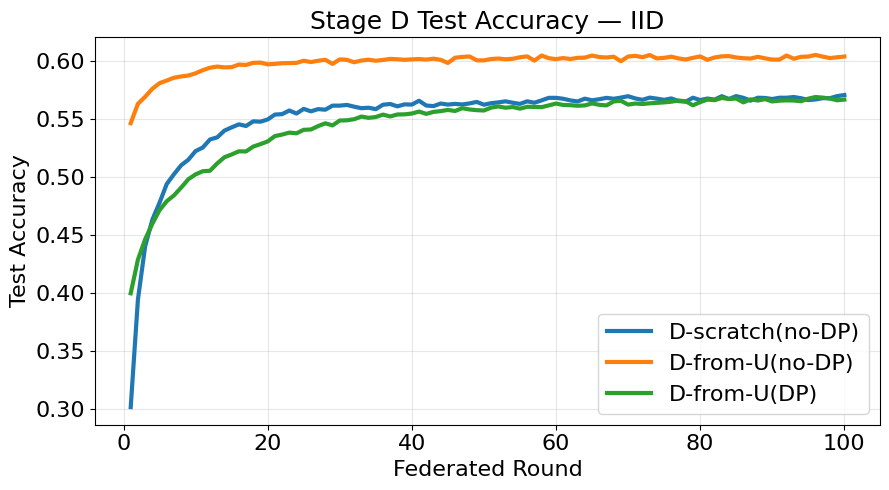

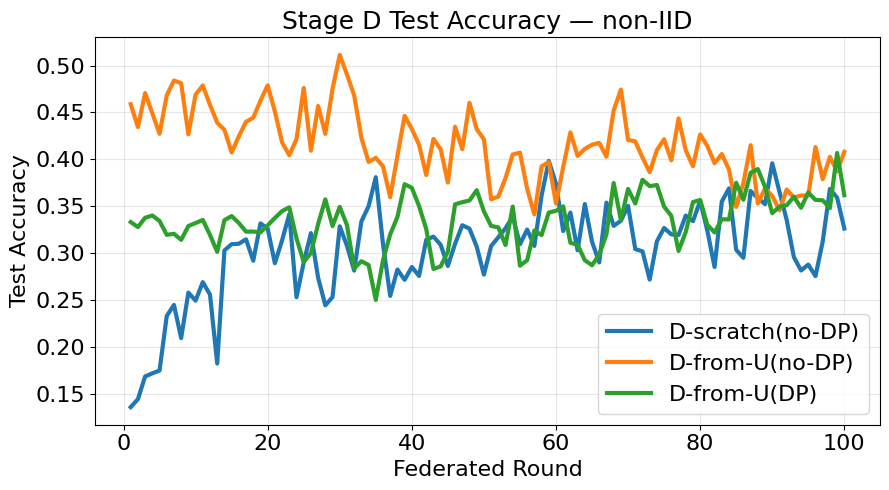

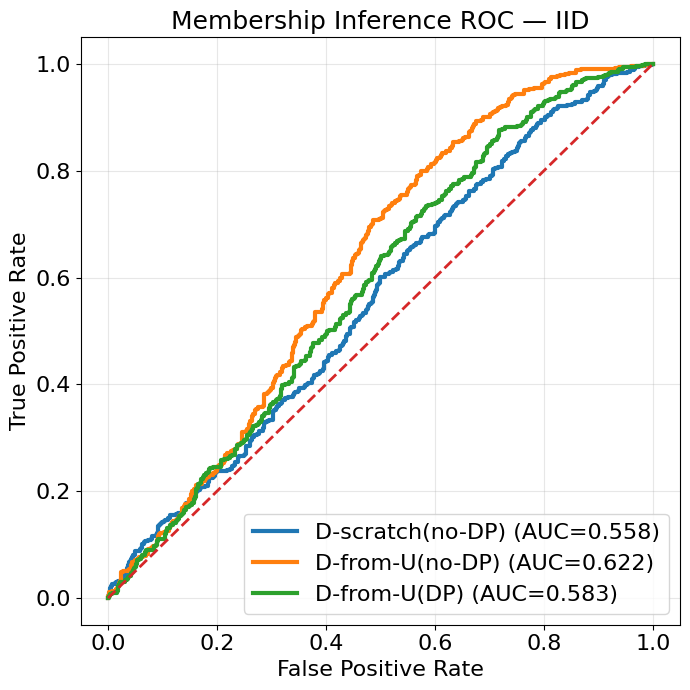

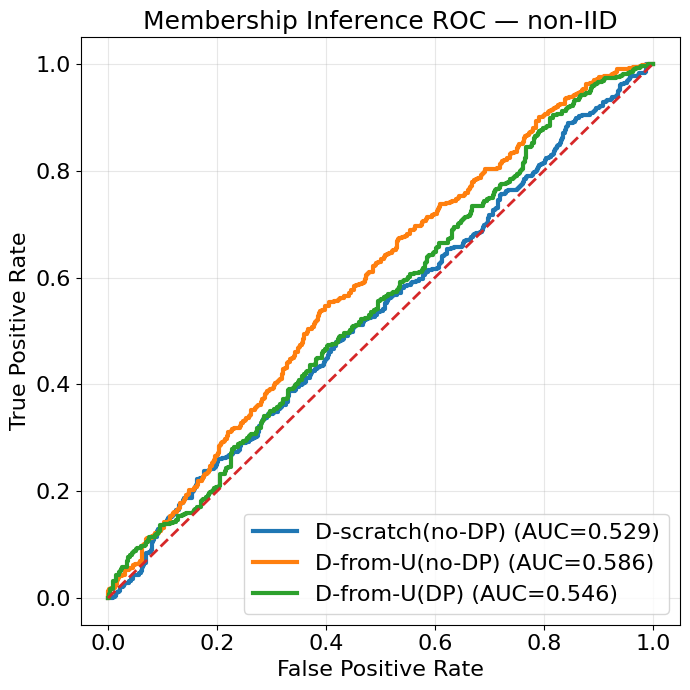

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Plot styling (font 16–18)
# -------------------------
TITLE_FS = 18
AXIS_FS  = 16
TICK_FS  = 16
LEG_FS   = 16
LINE_W   = 3      # thicker main lines
BASE_W   = 2      # thicker diagonal baseline

conds = ["D-scratch", "D-from-U(no-def)", "D-from-U(def)"]
pretty = {
    "D-scratch": "D-scratch(no-DP)",
    "D-from-U(no-def)": "D-from-U(no-DP)",
    "D-from-U(def)": "D-from-U(DP)",
}

def plot_accuracy_curves(setting, title=None):
    plt.figure(figsize=(9,5))
    rounds = np.arange(1, len(histories[setting][conds[0]]) + 1)

    for c in conds:
        plt.plot(rounds, histories[setting][c],
                 label=pretty[c],
                 linewidth=LINE_W)

    plt.title(title if title else f"Stage D Test Accuracy ({setting.upper()})", fontsize=TITLE_FS)
    plt.xlabel("Federated Round", fontsize=AXIS_FS)
    plt.ylabel("Test Accuracy", fontsize=AXIS_FS)
    plt.xticks(fontsize=TICK_FS)
    plt.yticks(fontsize=TICK_FS)
    plt.legend(fontsize=LEG_FS)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_mia_roc(setting, title=None):
    plt.figure(figsize=(7,7))

    for c in conds:
        fpr = results[setting][c]["fpr"]
        tpr = results[setting][c]["tpr"]
        auc = results[setting][c]["auc"]
        plt.plot(fpr, tpr,
                 label=f"{pretty[c]} (AUC={auc:.3f})",
                 linewidth=LINE_W)

    # diagonal baseline
    plt.plot([0,1], [0,1], linestyle="--", linewidth=BASE_W)

    plt.title(title if title else f"MIA ROC (Loss-threshold) — {setting.upper()}", fontsize=TITLE_FS)
    plt.xlabel("False Positive Rate", fontsize=AXIS_FS)
    plt.ylabel("True Positive Rate", fontsize=AXIS_FS)
    plt.xticks(fontsize=TICK_FS)
    plt.yticks(fontsize=TICK_FS)
    plt.legend(fontsize=LEG_FS, loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# -------------------------
# Requested plots
# -------------------------
plot_accuracy_curves("iid", title="Stage D Test Accuracy — IID")
plot_accuracy_curves("noniid", title="Stage D Test Accuracy — non-IID")

plot_mia_roc("iid", title="Membership Inference ROC — IID")
plot_mia_roc("noniid", title="Membership Inference ROC — non-IID")

##################

##Same IID and Non-IID for MNIST

##################

device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 341kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]


Num canaries: 500
Example client labels: [4, 3]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

[StageU-NO-DEF] Round 01/20 | test acc: 0.1833


[StageU-NO-DEF] Round 02/20 | test acc: 0.3477
[StageU-NO-DEF] Round 03/20 | test acc: 0.3144
[StageU-NO-DEF] Round 04/20 | test acc: 0.4144
[StageU-NO-DEF] Round 05/20 | test acc: 0.4701
[StageU-NO-DEF] Round 06/20 | test acc: 0.5058
[StageU-NO-DEF] Round 07/20 | test acc: 0.5546
[StageU-NO-DEF] Round 08/20 | test acc: 0.5771
[StageU-NO-DEF] Round 09/20 | test acc: 0.4103
[StageU-NO-DEF] Round 10/20 | test acc: 0.4656
[StageU-NO-DEF] Round 11/20 | test acc: 0.5773
[StageU-NO-DEF] Round 12/20 | test acc: 0.5268
[StageU-NO-DEF] Round 13/20 | test acc: 0.5325
[StageU-NO-DEF] Round 14/20 | test acc: 0.6073
[StageU-NO-DEF] Round 15/20 | test acc: 0.4449
[StageU-NO-DEF] Round 16/20 | test acc: 0.5554
[StageU-NO-DEF] Round 17/20 | test acc: 0.6597
[StageU-NO-DEF] Round 18/20 | test acc: 0.6637
[StageU-NO-DEF] Round 19/20 | test acc: 0.6549
[StageU-NO-DEF] Round 20/20 | test acc: 0.4286
[StageU-DEF] Round 01/20 | test acc: 0.1351
[StageU-DEF] Round 02/20 | test acc: 0.1722
[StageU-DEF] Round 

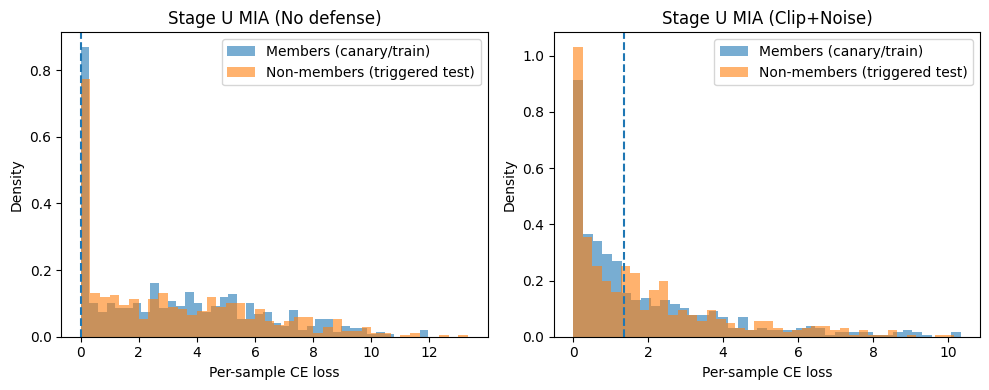

Saved figure: /content/drive/MyDrive/Sok_caseStudy/stageU_mnist_mia_hist.png
Saved CSV: /content/drive/MyDrive/Sok_caseStudy/stageU_mnist_mia_results.csv


,Stage,Dataset,Defense,Attack,AUC,BestAcc
0,U,MNIST,None,Loss-threshold MIA (canary),0.491484,0.509
1,U,MNIST,Clip+Noise,Loss-threshold MIA (canary),0.502084,0.531


In [ ]:
# =========================
# Stage U (FL-for-FMs) Case Study — MNIST + ViT-tiny (3-channel)
# - Simulated FL (clients + FedAvg) with non-IID partition
# - Two runs: no defense vs clip+noise defense on client deltas
# - Membership inference (loss-threshold) using CANARY members (triggered train samples)
# - Outputs: figure PNG + results CSV (paper-ready)
# =========================

!pip -q install timm torchvision pandas

import os, copy, random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------
# Repro + device + paths
# -------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

BASE_PATH = "/content/drive/MyDrive/Sok_caseStudy"
os.makedirs(BASE_PATH, exist_ok=True)


IMG_SIZE = 64
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # 1ch -> 3ch
    transforms.ToTensor(),
    transforms.Normalize((0.1307, 0.1307, 0.1307), (0.3081, 0.3081, 0.3081)),
])

transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.1307, 0.1307, 0.1307), (0.3081, 0.3081, 0.3081)),
])

train_raw = datasets.MNIST(root="./data", train=True, download=True, transform=transform_train)
test_raw  = datasets.MNIST(root="./data", train=False, download=True, transform=transform_test)

# -------------------------
# Canary trigger: corner patch
# -------------------------
def apply_patch(x, size=6, value=2.0):
    x = x.clone()
    x[:, :size, :size] = value
    return x

class TriggeredSubsetDS(Dataset):
    """
    Wrap a base dataset and apply a trigger to specified indices.
    """
    def __init__(self, base_ds, trigger_set=None, patch_size=6, patch_value=2.0):
        self.base = base_ds
        self.trigger_set = set(trigger_set) if trigger_set is not None else set()
        self.patch_size = patch_size
        self.patch_value = patch_value

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        if idx in self.trigger_set:
            x = apply_patch(x, size=self.patch_size, value=self.patch_value)
        return x, y

# Pick canary indices from TRAIN (members)
N_CANARY = 500
canary_idx = np.random.choice(len(train_raw), size=N_CANARY, replace=False).tolist()

# Training dataset: only canaries are triggered
train_ds = TriggeredSubsetDS(train_raw, trigger_set=canary_idx, patch_size=6, patch_value=2.0)

# Non-member candidates: triggered TEST samples (ALL test are triggered for distribution matching)
test_ds_triggered_all = TriggeredSubsetDS(test_raw, trigger_set=set(range(len(test_raw))), patch_size=6, patch_value=2.0)

print("Num canaries:", len(canary_idx))

# -------------------------
# Non-IID client partition (2 labels per client)
# -------------------------
def make_noniid_clients_by_labels(dataset, num_clients=20, labels_per_client=2):
    label_to_indices = {c: [] for c in range(10)}
    for i in range(len(dataset)):
        _, y = dataset[i]
        label_to_indices[int(y)].append(i)

    for c in label_to_indices:
        random.shuffle(label_to_indices[c])

    clients = {i: [] for i in range(num_clients)}
    all_labels = list(range(10))
    client_labels = []
    per_client = len(dataset) // num_clients

    for i in range(num_clients):
        chosen = random.sample(all_labels, labels_per_client)
        client_labels.append(chosen)
        while len(clients[i]) < per_client:
            y = random.choice(chosen)
            if label_to_indices[y]:
                clients[i].append(label_to_indices[y].pop())
            else:
                # fallback
                for yy in all_labels:
                    if label_to_indices[yy]:
                        clients[i].append(label_to_indices[yy].pop())
                        break
                else:
                    break

    return clients, client_labels

NUM_CLIENTS = 20
LABELS_PER_CLIENT = 2
client_indices, client_labels = make_noniid_clients_by_labels(train_ds, NUM_CLIENTS, LABELS_PER_CLIENT)

# Oversample canaries inside each client to encourage memorization signal
CANARY_REPEAT = 3
canary_set = set(canary_idx)
for cid in range(NUM_CLIENTS):
    extra = [idx for idx in client_indices[cid] if idx in canary_set]
    client_indices[cid].extend(extra * CANARY_REPEAT)

print("Example client labels:", client_labels[0])

# -------------------------
# ViT model (FM-like backbone)
# Train head + last transformer block (stronger leakage than head-only, still feasible)
# -------------------------
def build_vit(num_classes=10):
    model = timm.create_model(
        "vit_tiny_patch16_224",
        pretrained=True,
        img_size=IMG_SIZE,
        in_chans=3,
        num_classes=num_classes
    )
    return model

def set_trainable_head_lastblock(model):
    for n, p in model.named_parameters():
        p.requires_grad = False
        if n.startswith("head."):
            p.requires_grad = True
        if "blocks.11." in n:  # vit_tiny has 12 blocks: 0..11
            p.requires_grad = True
        if n.startswith("norm."):
            p.requires_grad = True

def get_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def load_state(model, state):
    model.load_state_dict(state, strict=True)

def trainable_param_names(model):
    # NOTE: state_dict keys differ from named_parameters keys.
    # We'll instead build "keys" using model.state_dict() and filtering by requires_grad masks.
    return [n for n, p in model.named_parameters() if p.requires_grad]

@torch.no_grad()
def evaluate_acc(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=2)
    correct = 0; total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

# -------------------------
# FL training utilities
# -------------------------
BATCH_SIZE = 64
ROUNDS = 20
CLIENTS_PER_ROUND = 5
LOCAL_EPOCHS = 5
LR = 5e-4

# Defense (clip+noise on deltas for trainable params only)
CLIP_NORM = 1.0
NOISE_STD = 0.02

def local_train_one_client(global_state, indices):
    model = build_vit(num_classes=10).to(device)
    set_trainable_head_lastblock(model)
    load_state(model, global_state)
    model.train()

    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)

    loader = DataLoader(Subset(train_ds, indices), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    for _ in range(LOCAL_EPOCHS):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()

    return get_state(model)

def compute_delta(global_state, local_state, keys):
    return {k: (local_state[k] - global_state[k]) for k in keys}

def clip_and_noise(delta, clip_norm, noise_std):
    total = 0.0
    for k in delta:
        total += torch.sum(delta[k] ** 2)
    total = torch.sqrt(total + 1e-12)
    coef = min(1.0, float(clip_norm / (total.item() + 1e-12)))
    out = {}
    for k in delta:
        d = delta[k] * coef
        d = d + torch.randn_like(d) * noise_std
        out[k] = d
    return out

def state_keys_for_trainable(model):
    """
    Build a conservative set of trainable state_dict keys.
    This avoids mismatches between named_parameters and state_dict naming.
    """
    trainable_param = {n for n, p in model.named_parameters() if p.requires_grad}
    # In timm ViT, parameter names generally match state_dict keys for weights/bias.
    # Buffers like running stats (if any) are excluded by this intersection.
    return trainable_param

def run_stage_u(defense=False):
    global_model = build_vit(num_classes=10).to(device)
    set_trainable_head_lastblock(global_model)
    global_state = get_state(global_model)

    # Trainable keys for aggregation
    keys = [k for k in global_state.keys() if k in state_keys_for_trainable(global_model)]

    for r in range(1, ROUNDS + 1):
        selected = random.sample(range(NUM_CLIENTS), CLIENTS_PER_ROUND)
        deltas = []
        sizes = []

        for cid in selected:
            local_state = local_train_one_client(global_state, client_indices[cid])
            delta = compute_delta(global_state, local_state, keys)
            if defense:
                delta = clip_and_noise(delta, CLIP_NORM, NOISE_STD)
            deltas.append(delta)
            sizes.append(len(client_indices[cid]))
            torch.cuda.empty_cache()

        w = np.array(sizes, dtype=np.float64)
        w = w / w.sum()

        for k in keys:
            global_state[k] = global_state[k] + sum(float(wi) * di[k] for wi, di in zip(w, deltas))

        load_state(global_model, global_state)
        acc = evaluate_acc(global_model, test_raw)
        tag = "DEF" if defense else "NO-DEF"
        print(f"[StageU-{tag}] Round {r:02d}/{ROUNDS} | test acc: {acc:.4f}")

    return global_state

# -------------------------
# Train both Stage-U artifacts and save
# -------------------------
state_no_def = run_stage_u(defense=False)
path_no_def = os.path.join(BASE_PATH, "stageU_mnist_no_defense.pt")
torch.save(state_no_def, path_no_def)

state_def = run_stage_u(defense=True)
path_def = os.path.join(BASE_PATH, "stageU_mnist_with_defense.pt")
torch.save(state_def, path_def)

np.save(os.path.join(BASE_PATH, "mnist_canary_indices.npy"), np.array(canary_idx, dtype=np.int64))

print("Saved:", path_no_def)
print("Saved:", path_def)

# -------------------------
# Membership inference (loss-threshold) on triggered canaries
# - Members: triggered TRAIN canaries
# - Non-members: triggered TEST samples (same size)
# -------------------------
def load_model_from_state(state_path):
    model = build_vit(num_classes=10).to(device)
    set_trainable_head_lastblock(model)
    st = torch.load(state_path, map_location="cpu")
    model.load_state_dict(st, strict=True)
    model.eval()
    return model

@torch.no_grad()
def per_sample_losses(model, dataset, indices, bs=128):
    loader = DataLoader(Subset(dataset, indices), batch_size=bs, shuffle=False, num_workers=2)
    out = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y, reduction="none")
        out.extend(loss.detach().cpu().numpy().tolist())
    return np.array(out)

def roc_auc(scores, labels):
    scores = np.asarray(scores)
    labels = np.asarray(labels).astype(int)
    order = np.argsort(scores)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(scores)) + 1.0
    pos = labels == 1
    n_pos = pos.sum()
    n_neg = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        return np.nan
    sum_ranks_pos = ranks[pos].sum()
    auc = (sum_ranks_pos - n_pos*(n_pos+1)/2.0) / (n_pos*n_neg)
    return float(auc)

def best_thresh_acc(losses, labels):
    losses = np.asarray(losses)
    labels = np.asarray(labels).astype(int)
    uniq = np.unique(losses)
    step = max(1, len(uniq)//2000)
    best_acc, best_thr = 0.0, None
    for thr in uniq[::step]:
        pred = (losses <= thr).astype(int)
        acc = (pred == labels).mean()
        if acc > best_acc:
            best_acc, best_thr = acc, thr
    return float(best_acc), float(best_thr)

rng = np.random.default_rng(SEED)
nonmember_test_idx = rng.choice(len(test_raw), size=len(canary_idx), replace=False).tolist()

def run_mia(state_path, title):
    model = load_model_from_state(state_path)

    mem_losses = per_sample_losses(model, train_ds, canary_idx)
    non_losses = per_sample_losses(model, test_ds_triggered_all, nonmember_test_idx)

    losses = np.concatenate([mem_losses, non_losses])
    labels = np.concatenate([np.ones_like(mem_losses), np.zeros_like(non_losses)])

    scores = -losses
    auc = roc_auc(scores, labels)

    best_acc, thr = best_thresh_acc(losses, labels)

    print(f"\n{title}")
    print(f"ROC-AUC: {auc:.4f}  (using score = -loss)")
    print(f"BestAcc: {best_acc:.4f} @ loss <= {thr:.4f}")

    return auc, best_acc, thr, mem_losses, non_losses

auc0, acc0, thr0, mem0, non0 = run_mia(path_no_def, "Stage U (MNIST, no defense)")
auc1, acc1, thr1, mem1, non1 = run_mia(path_def,    "Stage U (MNIST, clip+noise)")

# -------------------------
# Paper-ready figure + CSV table
# -------------------------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(mem0, bins=40, alpha=0.6, density=True, label="Members (canary/train)")
plt.hist(non0, bins=40, alpha=0.6, density=True, label="Non-members (triggered test)")
plt.axvline(thr0, linestyle="--")
plt.title("Stage U MIA (No defense)")
plt.xlabel("Per-sample CE loss"); plt.ylabel("Density"); plt.legend()

plt.subplot(1,2,2)
plt.hist(mem1, bins=40, alpha=0.6, density=True, label="Members (canary/train)")
plt.hist(non1, bins=40, alpha=0.6, density=True, label="Non-members (triggered test)")
plt.axvline(thr1, linestyle="--")
plt.title("Stage U MIA (Clip+Noise)")
plt.xlabel("Per-sample CE loss"); plt.ylabel("Density"); plt.legend()

fig_path = os.path.join(BASE_PATH, "stageU_mnist_mia_hist.png")
plt.tight_layout()
plt.savefig(fig_path, dpi=200)
plt.show()
print("Saved figure:", fig_path)

df = pd.DataFrame([
    {"Stage": "U", "Dataset": "MNIST", "Defense": "None",       "Attack": "Loss-threshold MIA (canary)", "AUC": auc0, "BestAcc": acc0},
    {"Stage": "U", "Dataset": "MNIST", "Defense": "Clip+Noise", "Attack": "Loss-threshold MIA (canary)", "AUC": auc1, "BestAcc": acc1},
])
csv_path = os.path.join(BASE_PATH, "stageU_mnist_mia_results.csv")
df.to_csv(csv_path, index=False)
print("Saved CSV:", csv_path)

df

In [ ]:
# =========================
# Stage D (FMs-in-FL) — MNIST + ViT-tiny (3-channel)
# IID and non-IID, 30 clients, 100 rounds
# Three inits: D-scratch, D-from-U(no-def), D-from-U(def)
# Freeze backbone, train head via FL, then MIA on canaries
# Outputs: checkpoints + results dicts for plotting
# =========================

import os, copy, random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
import timm
import pandas as pd

# -------------------------
# Repro + device + paths
# -------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

BASE_PATH = "/content/drive/MyDrive/Sok_caseStudy"
os.makedirs(BASE_PATH, exist_ok=True)

# >>> UPDATE THESE THREE MNIST FILE NAMES (Stage U + canaries) <<<
u_no_def_path = os.path.join(BASE_PATH, "stageU_mnist_no_defense.pt")
u_def_path    = os.path.join(BASE_PATH, "stageU_mnist_with_defense.pt")
canary_path   = os.path.join(BASE_PATH, "mnist_canary_indices.npy")

assert os.path.exists(u_no_def_path), f"Missing {u_no_def_path}"
assert os.path.exists(u_def_path),    f"Missing {u_def_path}"
assert os.path.exists(canary_path),   f"Missing {canary_path}"

# -------------------------
# MNIST preprocessing (ViT expects 3-channel; we convert 1->3)
# -------------------------
IMG_SIZE = 64
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # 1-channel -> 3-channel
    transforms.ToTensor(),
    transforms.Normalize((0.1307, 0.1307, 0.1307), (0.3081, 0.3081, 0.3081))  # MNIST stats replicated
])

train_raw = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_raw  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# -------------------------
# Canary trigger (patch)
# -------------------------
def apply_patch(x, size=6, value=2.0):
    x = x.clone()
    x[:, :size, :size] = value
    return x

class TriggeredSubsetDS(Dataset):
    def __init__(self, base_ds, trigger_set=None, patch_size=6, patch_value=2.0):
        self.base = base_ds
        self.trigger_set = set(trigger_set) if trigger_set is not None else set()
        self.patch_size = patch_size
        self.patch_value = patch_value

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        if idx in self.trigger_set:
            x = apply_patch(x, size=self.patch_size, value=self.patch_value)
        return x, y

canary_idx = np.load(canary_path).astype(int).tolist()
canary_set = set(canary_idx)
print("Loaded canaries:", len(canary_idx))

# Stage D training dataset: triggered canaries in TRAIN
train_ds = TriggeredSubsetDS(train_raw, trigger_set=canary_set, patch_size=6, patch_value=2.0)

# Non-member evaluation dataset: triggered TEST (all test samples triggered)
test_ds_triggered_all = TriggeredSubsetDS(test_raw, trigger_set=set(range(len(test_raw))), patch_size=6, patch_value=2.0)

# -------------------------
# Client partitioning: IID + non-IID
# -------------------------
def make_iid_clients(dataset_len, num_clients=30):
    idx = np.arange(dataset_len)
    rng = np.random.default_rng(SEED)
    rng.shuffle(idx)
    splits = np.array_split(idx, num_clients)
    return {i: splits[i].tolist() for i in range(num_clients)}

def make_noniid_clients_by_labels(dataset, num_clients=30, labels_per_client=2):
    label_to_indices = {c: [] for c in range(10)}
    for i in range(len(dataset)):
        _, y = dataset[i]
        label_to_indices[int(y)].append(i)
    for c in label_to_indices:
        random.shuffle(label_to_indices[c])

    clients = {i: [] for i in range(num_clients)}
    all_labels = list(range(10))
    client_labels = []
    per_client = len(dataset) // num_clients

    for i in range(num_clients):
        chosen = random.sample(all_labels, labels_per_client)
        client_labels.append(chosen)
        while len(clients[i]) < per_client:
            y = random.choice(chosen)
            if label_to_indices[y]:
                clients[i].append(label_to_indices[y].pop())
            else:
                for yy in all_labels:
                    if label_to_indices[yy]:
                        clients[i].append(label_to_indices[yy].pop())
                        break
                else:
                    break
    return clients, client_labels

NUM_CLIENTS = 30
LABELS_PER_CLIENT = 2

client_indices_iid = make_iid_clients(len(train_ds), NUM_CLIENTS)
client_indices_noniid, client_labels_noniid = make_noniid_clients_by_labels(train_ds, NUM_CLIENTS, LABELS_PER_CLIENT)
print("Non-IID example client labels:", client_labels_noniid[0])


CANARY_REPEAT_D = 10
def repeat_canaries_in_clients(client_indices_dict, canary_set, repeat_factor):
    out = {}
    for cid, idxs in client_indices_dict.items():
        idxs = list(idxs)
        extra = [ix for ix in idxs if ix in canary_set]
        idxs.extend(extra * repeat_factor)
        out[cid] = idxs
    return out

client_indices_iid    = repeat_canaries_in_clients(client_indices_iid, canary_set, CANARY_REPEAT_D)
client_indices_noniid = repeat_canaries_in_clients(client_indices_noniid, canary_set, CANARY_REPEAT_D)


def build_vit(num_classes=10):
    return timm.create_model(
        "vit_tiny_patch16_224",
        pretrained=True,
        img_size=IMG_SIZE,
        in_chans=3,
        num_classes=num_classes
    )

def set_trainable_head_only(model):
    for n, p in model.named_parameters():
        p.requires_grad = n.startswith("head.")

def get_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def load_state(model, state):
    model.load_state_dict(state, strict=True)

@torch.no_grad()
def evaluate_acc(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=2)
    correct = 0; total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total


BATCH_SIZE = 64
ROUNDS_D = 100
CLIENTS_PER_ROUND_D = 10
LOCAL_EPOCHS_D = 1
LR_D = 5e-4

def local_train_client_head(global_state, indices):
    model = build_vit(num_classes=10).to(device)
    set_trainable_head_only(model)
    load_state(model, global_state)
    model.train()

    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR_D)
    loader = DataLoader(Subset(train_ds, indices), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

    for _ in range(LOCAL_EPOCHS_D):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()

    return get_state(model)

def run_stage_d(client_indices, init_state=None, tag="D"):
    model = build_vit(num_classes=10).to(device)
    set_trainable_head_only(model)

    if init_state is not None:
        load_state(model, init_state)

    global_state = get_state(model)
    head_keys = [k for k in global_state.keys() if k.startswith("head.")]
    acc_hist = []

    for r in range(1, ROUNDS_D + 1):
        selected = random.sample(range(NUM_CLIENTS), CLIENTS_PER_ROUND_D)
        deltas = []
        sizes = []

        for cid in selected:
            local_state = local_train_client_head(global_state, client_indices[cid])
            delta = {k: (local_state[k] - global_state[k]) for k in head_keys}
            deltas.append(delta)
            sizes.append(len(client_indices[cid]))
            torch.cuda.empty_cache()

        w = np.array(sizes, dtype=np.float64)
        w = w / w.sum()

        for k in head_keys:
            global_state[k] = global_state[k] + sum(float(wi) * di[k] for wi, di in zip(w, deltas))

        load_state(model, global_state)
        acc = evaluate_acc(model, test_raw)
        acc_hist.append(acc)

        if (r % 5 == 0) or (r == 1) or (r == ROUNDS_D):
            print(f"[{tag}] Round {r:03d}/{ROUNDS_D} | test acc: {acc:.4f}")

    return global_state, np.array(acc_hist, dtype=np.float32)

# Load Stage U initializations (MNIST)
u_no_def_state = torch.load(u_no_def_path, map_location="cpu")
u_def_state    = torch.load(u_def_path, map_location="cpu")

# -------------------------
# MIA utilities (ROC + AUC + best threshold acc)
# -------------------------
@torch.no_grad()
def per_sample_losses(model, dataset, indices, bs=128):
    loader = DataLoader(Subset(dataset, indices), batch_size=bs, shuffle=False, num_workers=2)
    out = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y, reduction="none")
        out.extend(loss.detach().cpu().numpy().tolist())
    return np.array(out)

def roc_curve_from_scores(scores, labels):
    scores = np.asarray(scores)
    labels = np.asarray(labels).astype(int)

    order = np.argsort(scores)[::-1]
    scores_sorted = scores[order]
    labels_sorted = labels[order]

    P = labels_sorted.sum()
    N = len(labels_sorted) - P
    if P == 0 or N == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 1.0]), np.array([np.inf, -np.inf])

    tps = np.cumsum(labels_sorted == 1)
    fps = np.cumsum(labels_sorted == 0)

    tpr = tps / P
    fpr = fps / N

    tpr = np.concatenate([[0.0], tpr, [1.0]])
    fpr = np.concatenate([[0.0], fpr, [1.0]])
    thr = np.concatenate([[np.inf], scores_sorted, [-np.inf]])
    return fpr, tpr, thr

def auc_from_roc(fpr, tpr):
    return float(np.trapz(tpr, fpr))

def best_thresh_acc(losses, labels):
    losses = np.asarray(losses)
    labels = np.asarray(labels).astype(int)
    uniq = np.unique(losses)
    step = max(1, len(uniq)//2000)
    best_acc, best_thr = 0.0, None
    for thr in uniq[::step]:
        pred = (losses <= thr).astype(int)
        acc = (pred == labels).mean()
        if acc > best_acc:
            best_acc, best_thr = acc, thr
    return float(best_acc), float(best_thr)

def load_model_from_state_dict(state_dict):
    m = build_vit(num_classes=10).to(device)
    set_trainable_head_only(m)
    m.load_state_dict(state_dict, strict=True)
    m.eval()
    return m

rng = np.random.default_rng(SEED)
nonmember_test_idx = rng.choice(len(test_raw), size=len(canary_idx), replace=False).tolist()

def run_mia_on_state(state_dict, title):
    model = load_model_from_state_dict(state_dict)

    mem_losses = per_sample_losses(model, train_ds, canary_idx)
    non_losses = per_sample_losses(model, test_ds_triggered_all, nonmember_test_idx)

    losses = np.concatenate([mem_losses, non_losses])
    labels = np.concatenate([np.ones_like(mem_losses), np.zeros_like(non_losses)])

    scores = -losses
    fpr, tpr, thr = roc_curve_from_scores(scores, labels)
    auc = auc_from_roc(fpr, tpr)
    best_acc, best_thr = best_thresh_acc(losses, labels)

    print(f"\n{title}")
    print(f"ROC-AUC: {auc:.4f}")
    print(f"BestAcc: {best_acc:.4f} @ loss <= {best_thr:.4f}")

    return {
        "auc": auc,
        "best_acc": best_acc,
        "best_thr": best_thr,
        "mem_losses": mem_losses,
        "non_losses": non_losses,
        "fpr": fpr,
        "tpr": tpr,
    }

# -------------------------
# Run IID + non-IID, each with 3 conditions
# -------------------------
results = {"iid": {}, "noniid": {}}
histories = {"iid": {}, "noniid": {}}

def run_all_for_setting(setting_name, client_indices):
    print("\n" + "="*80)
    print(f"RUNNING SETTING: {setting_name.upper()} | clients={NUM_CLIENTS} | rounds={ROUNDS_D}")
    print("="*80)

    d_scratch_state, acc_s = run_stage_d(client_indices, init_state=None, tag=f"{setting_name}:D-scratch")
    d_u0_state, acc_u0 = run_stage_d(client_indices, init_state=u_no_def_state, tag=f"{setting_name}:D-from-U(no-def)")
    d_u1_state, acc_u1 = run_stage_d(client_indices, init_state=u_def_state, tag=f"{setting_name}:D-from-U(def)")

    out_paths = {
        "D-scratch": os.path.join(BASE_PATH, f"stageD_mnist_{setting_name}_from_scratch.pt"),
        "D-from-U(no-def)": os.path.join(BASE_PATH, f"stageD_mnist_{setting_name}_from_U_no_def.pt"),
        "D-from-U(def)": os.path.join(BASE_PATH, f"stageD_mnist_{setting_name}_from_U_def.pt"),
    }
    torch.save(d_scratch_state, out_paths["D-scratch"])
    torch.save(d_u0_state, out_paths["D-from-U(no-def)"])
    torch.save(d_u1_state, out_paths["D-from-U(def)"])
    print("\nSaved Stage D checkpoints:")
    for k,v in out_paths.items():
        print(" ", k, "->", v)

    mia_s  = run_mia_on_state(d_scratch_state,  f"{setting_name.upper()} | Stage D (from scratch)")
    mia_u0 = run_mia_on_state(d_u0_state,       f"{setting_name.upper()} | Stage D (from U no-def)")
    mia_u1 = run_mia_on_state(d_u1_state,       f"{setting_name.upper()} | Stage D (from U def)")

    histories[setting_name]["D-scratch"] = acc_s
    histories[setting_name]["D-from-U(no-def)"] = acc_u0
    histories[setting_name]["D-from-U(def)"] = acc_u1

    results[setting_name]["D-scratch"] = mia_s
    results[setting_name]["D-from-U(no-def)"] = mia_u0
    results[setting_name]["D-from-U(def)"] = mia_u1

run_all_for_setting("iid", client_indices_iid)
run_all_for_setting("noniid", client_indices_noniid)

# -------------------------
# Save CSV summary
# -------------------------
rows = []
for setting in ["iid", "noniid"]:
    for cond in ["D-scratch", "D-from-U(no-def)", "D-from-U(def)"]:
        rows.append({
            "Setting": setting,
            "Stage": "D",
            "Init": cond.replace("D-", ""),
            "Attack": "Loss-threshold MIA (canary)",
            "AUC": results[setting][cond]["auc"],
            "BestAcc": results[setting][cond]["best_acc"],
            "BestThr": results[setting][cond]["best_thr"],
        })

df = pd.DataFrame(rows)
csv_path = os.path.join(BASE_PATH, "stageD_mnist_mia_results_iid_vs_noniid_100round_30clients.csv")
df.to_csv(csv_path, index=False)
print("\nSaved CSV:", csv_path)

df

device: cuda
Loaded canaries: 500
Non-IID example client labels: [4, 3]

RUNNING SETTING: IID | clients=30 | rounds=100
[iid:D-scratch] Round 001/100 | test acc: 0.3475
[iid:D-scratch] Round 005/100 | test acc: 0.6723
[iid:D-scratch] Round 010/100 | test acc: 0.7177
[iid:D-scratch] Round 015/100 | test acc: 0.7385
[iid:D-scratch] Round 020/100 | test acc: 0.7573
[iid:D-scratch] Round 025/100 | test acc: 0.7677
[iid:D-scratch] Round 030/100 | test acc: 0.7743
[iid:D-scratch] Round 035/100 | test acc: 0.7800
[iid:D-scratch] Round 040/100 | test acc: 0.7843
[iid:D-scratch] Round 045/100 | test acc: 0.7882
[iid:D-scratch] Round 050/100 | test acc: 0.7943
[iid:D-scratch] Round 055/100 | test acc: 0.7969
[iid:D-scratch] Round 060/100 | test acc: 0.7996
[iid:D-scratch] Round 065/100 | test acc: 0.8036
[iid:D-scratch] Round 070/100 | test acc: 0.8039
[iid:D-scratch] Round 075/100 | test acc: 0.8091
[iid:D-scratch] Round 080/100 | test acc: 0.8077
[iid:D-scratch] Round 085/100 | test acc: 0.809

/tmp/ipython-input-3082/4157455651.py:293: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(tpr, fpr))



IID | Stage D (from scratch)
ROC-AUC: 0.5127
BestAcc: 0.5230 @ loss <= 0.1975

IID | Stage D (from U no-def)
ROC-AUC: 0.5090
BestAcc: 0.5420 @ loss <= 0.4953

IID | Stage D (from U def)
ROC-AUC: 0.5224
BestAcc: 0.5330 @ loss <= 0.1692

RUNNING SETTING: NONIID | clients=30 | rounds=100
[noniid:D-scratch] Round 001/100 | test acc: 0.1396
[noniid:D-scratch] Round 005/100 | test acc: 0.2525
[noniid:D-scratch] Round 010/100 | test acc: 0.3287
[noniid:D-scratch] Round 015/100 | test acc: 0.2851
[noniid:D-scratch] Round 020/100 | test acc: 0.4195
[noniid:D-scratch] Round 025/100 | test acc: 0.3345
[noniid:D-scratch] Round 030/100 | test acc: 0.3965
[noniid:D-scratch] Round 035/100 | test acc: 0.3934
[noniid:D-scratch] Round 040/100 | test acc: 0.3416
[noniid:D-scratch] Round 045/100 | test acc: 0.3297
[noniid:D-scratch] Round 050/100 | test acc: 0.4212
[noniid:D-scratch] Round 055/100 | test acc: 0.4554
[noniid:D-scratch] Round 060/100 | test acc: 0.4399
[noniid:D-scratch] Round 065/100 | te

,Setting,Stage,Init,Attack,AUC,BestAcc,BestThr
0,iid,D,scratch,Loss-threshold MIA (canary),0.512688,0.523,0.197513
1,iid,D,from-U(no-def),Loss-threshold MIA (canary),0.509040,0.542,0.495337
2,iid,D,from-U(def),Loss-threshold MIA (canary),0.522352,0.533,0.169166
3,noniid,D,scratch,Loss-threshold MIA (canary),0.490748,0.507,2.323315
4,noniid,D,from-U(no-def),Loss-threshold MIA (canary),0.497936,0.522,0.637054
5,noniid,D,from-U(def),Loss-threshold MIA (canary),0.528312,0.541,0.760956


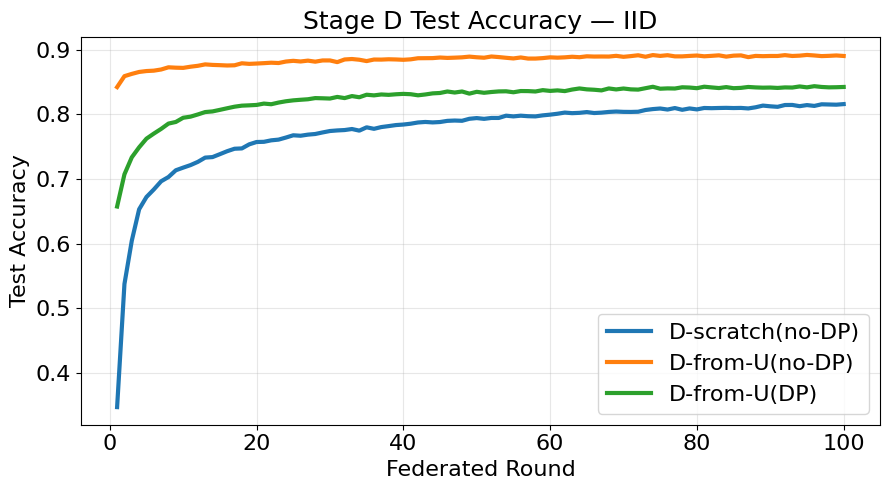

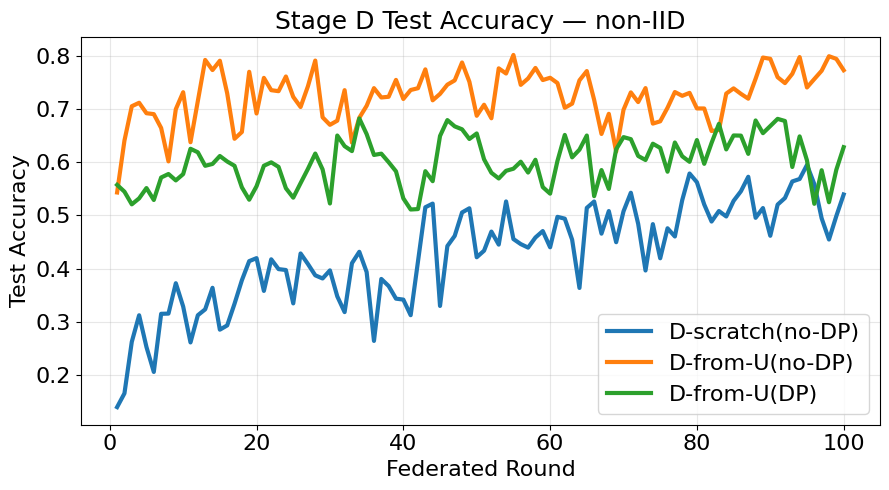

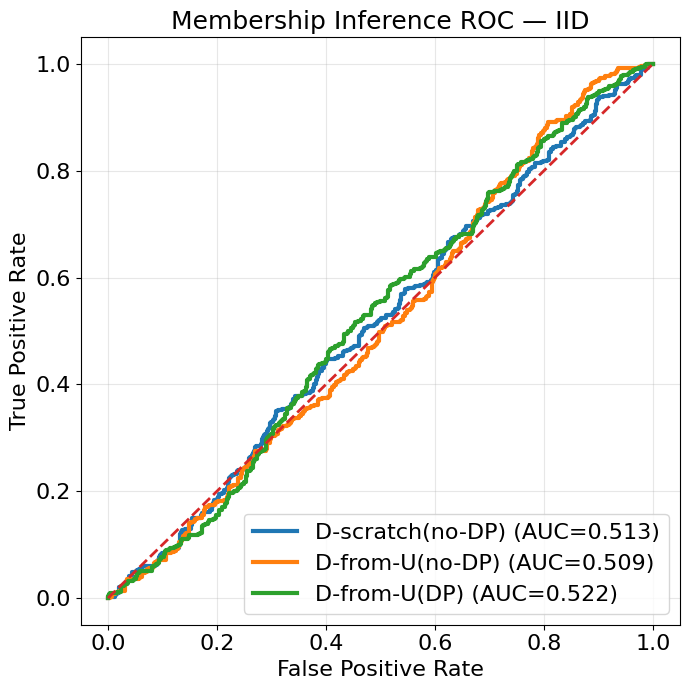

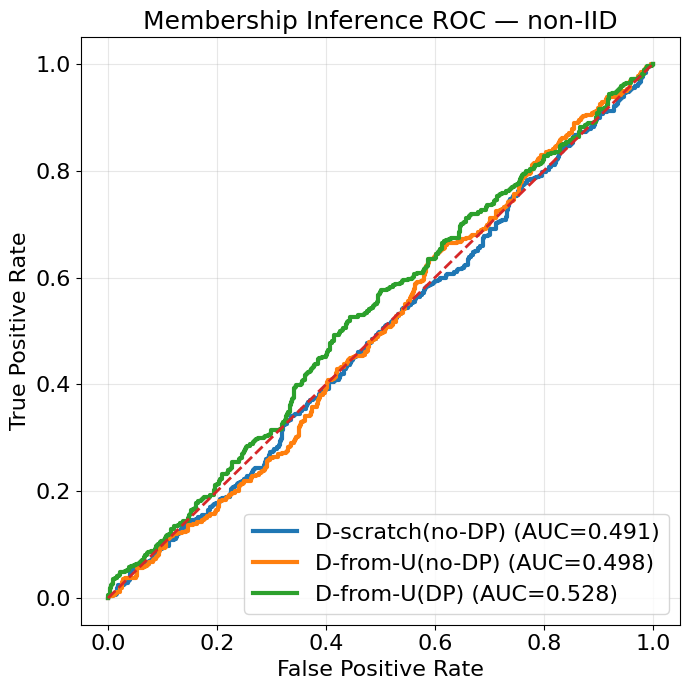

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


TITLE_FS = 18
AXIS_FS  = 16
TICK_FS  = 16
LEG_FS   = 16
LINE_W   = 3      # thicker main lines
BASE_W   = 2      # thicker diagonal baseline

conds = ["D-scratch", "D-from-U(no-def)", "D-from-U(def)"]
pretty = {
    "D-scratch": "D-scratch(no-DP)",
    "D-from-U(no-def)": "D-from-U(no-DP)",
    "D-from-U(def)": "D-from-U(DP)",
}

def plot_accuracy_curves(setting, title=None):
    plt.figure(figsize=(9,5))
    rounds = np.arange(1, len(histories[setting][conds[0]]) + 1)

    for c in conds:
        plt.plot(rounds, histories[setting][c],
                 label=pretty[c],
                 linewidth=LINE_W)

    plt.title(title if title else f"Stage D Test Accuracy ({setting.upper()})", fontsize=TITLE_FS)
    plt.xlabel("Federated Round", fontsize=AXIS_FS)
    plt.ylabel("Test Accuracy", fontsize=AXIS_FS)
    plt.xticks(fontsize=TICK_FS)
    plt.yticks(fontsize=TICK_FS)
    plt.legend(fontsize=LEG_FS)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_mia_roc(setting, title=None):
    plt.figure(figsize=(7,7))

    for c in conds:
        fpr = results[setting][c]["fpr"]
        tpr = results[setting][c]["tpr"]
        auc = results[setting][c]["auc"]
        plt.plot(fpr, tpr,
                 label=f"{pretty[c]} (AUC={auc:.3f})",
                 linewidth=LINE_W)

    # diagonal baseline
    plt.plot([0,1], [0,1], linestyle="--", linewidth=BASE_W)

    plt.title(title if title else f"MIA ROC (Loss-threshold) — {setting.upper()}", fontsize=TITLE_FS)
    plt.xlabel("False Positive Rate", fontsize=AXIS_FS)
    plt.ylabel("True Positive Rate", fontsize=AXIS_FS)
    plt.xticks(fontsize=TICK_FS)
    plt.yticks(fontsize=TICK_FS)
    plt.legend(fontsize=LEG_FS, loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# -------------------------
# Requested plots
# -------------------------
plot_accuracy_curves("iid", title="Stage D Test Accuracy — IID")
plot_accuracy_curves("noniid", title="Stage D Test Accuracy — non-IID")

plot_mia_roc("iid", title="Membership Inference ROC — IID")
plot_mia_roc("noniid", title="Membership Inference ROC — non-IID")